# TVDE Lisbon — Driver Analytics
## Notebook 01: Data Cleaning, Validation & Statistical Analysis

**Author:** Gabriel | Lisbon, Portugal | 2026  
**Data source:** Real ride-hailing data collected manually from Uber and Bolt driver apps  
**Period:** March – August 2026  

---

### Notebook Structure

| Block | Topic |
|---|---|
| Block 1 | Data Quality & Validation |
| Block 2 | Statistical Relationships |
| Block 3 | Temporal Patterns |
| Block 4 | Ride Profile |
| Block 5 | Acceptance Criteria |

> **Note:** All monetary values represent driver net earnings (Driver_Earnings_EUR).  
> Platform fees, tolls and tips are excluded — see README for full methodology.

---
## Block 1 — Data Quality & Validation

Before any analysis, the dataset is inspected for missing values, type inconsistencies,
duplicate entries and outliers. This block documents every decision made during the
cleaning process.

### Setup — Environment Check

Verify that all required libraries are installed before loading the data.

In [1]:
# Environment test — checking required libraries

import sys
print(f"Python version: {sys.version}")
print("-" * 50)

libraries = ["pandas", "numpy", "matplotlib", "seaborn", "openpyxl"]

for lib in libraries:
    try:
        module = __import__(lib)
        version = getattr(module, "__version__", "unknown")
        print(f"✅ {lib} — installed (version {version})")
    except ImportError:
        print(f"❌ {lib} — NOT installed")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
--------------------------------------------------
✅ pandas — installed (version 2.3.3)
✅ numpy — installed (version 2.4.1)
✅ matplotlib — installed (version 3.10.8)
✅ seaborn — installed (version 0.13.2)
✅ openpyxl — installed (version 3.1.5)


### Step 1 — Load Raw Data

Load the Excel file and inspect the initial shape and column names.

In [2]:
# Load the raw data file

import pandas as pd

file_path = r"C:\Users\gabri\Documents\Projetos\tvde-lisboa-analysis\data\raw\TVDE_In.xlsx"

df = pd.read_excel(file_path, sheet_name="Rides")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("-" * 50)
print(df.columns.tolist())

Rows: 2600
Columns: 19
--------------------------------------------------
['Ride_ID', 'Platform', 'Category', 'Date', 'Start_Time', 'End_Time', 'Duration_Min', 'Origin_PostCode', 'Dest_PostCode', 'Distance_Km', 'Client_Fare_EUR', 'Driver_Earnings_EUR', 'Platform_Fee_EUR', 'Fee_Pct', 'EUR_per_Km', 'EUR_per_Min', 'Portagem', 'Dinamica', 'Tip']


### Step 2 — Select Relevant Columns

Several columns are excluded from this analysis. The focus is on the driver's
perspective — platform economics, toll reimbursements and tips are out of scope.
See README for full justification of each exclusion.

In [3]:
# Keep only the columns relevant to this project's scope
# Platform_Fee_EUR, Fee_Pct, Portagem, Dinamica and Tip are excluded —
# this project focuses on the driver's net outcome, not platform economics

columns_to_use = [
    "Ride_ID", "Platform", "Category", "Date", "Start_Time", "End_Time",
    "Duration_Min", "Origin_PostCode", "Dest_PostCode", "Distance_Km",
    "Client_Fare_EUR", "Driver_Earnings_EUR"
]

df = df[columns_to_use]

print(f"Shape after column selection: {df.shape}")
df.head()

Shape after column selection: (2600, 12)


,Ride_ID,Platform,Category,Date,Start_Time,End_Time,Duration_Min,Origin_PostCode,Dest_PostCode,Distance_Km,Client_Fare_EUR,Driver_Earnings_EUR
0,R013,Uber,Uber X,2026-03-04,19:29:00,19:54:00,25.0,2785-115,2675-663,24.44,14.69,9.66
1,R003,Bolt,Economy,2026-03-04,20:08:00,20:23:00,15.0,2675-472,1600-196,10.20,5.90,4.42
2,R009,Uber,Uber X,2026-03-04,16:49:00,17:12:00,23.0,2635-304,2610-244,14.49,9.93,6.87
3,R005,Uber,Uber X,2026-03-04,14:06:00,14:30:00,24.0,2690-182,1250-096,16.60,10.96,7.99
4,R002,Bolt,Economy,2026-03-04,19:11:00,19:36:00,25.0,1500-663,2785-816,17.20,11.66,8.92


### Step 3 — Fix Naming Inconsistencies

During data collection, minor inconsistencies were introduced in the Platform and
Category columns (trailing spaces, wrong capitalisation). These are corrected
automatically at load time.

In [4]:
# Fix inconsistent category naming — applied at load time
# 'Uber X ' (trailing space) and 'courier' (wrong capitalisation) detected
df["Category"] = df["Category"].str.strip()
df["Category"] = df["Category"].str.title()

print("Category cleanup applied.")
print(df["Category"].value_counts())

Category cleanup applied.
Category
Uber X             985
Economy            661
Bolt               609
Uber X Priority    252
Share               27
Courier              5
Priority             1
Accessibility        1
Name: count, dtype: int64


### Step 4 — Data Types & Missing Values

Check the data type of each column and count missing values.

In [5]:
# Check data types and missing values

print("DATA TYPES")
print("-" * 50)
print(df.dtypes)

print("\nMISSING VALUES")
print("-" * 50)
print(df.isnull().sum())

DATA TYPES
--------------------------------------------------
Ride_ID                        object
Platform                       object
Category                       object
Date                   datetime64[ns]
Start_Time                     object
End_Time                       object
Duration_Min                  float64
Origin_PostCode                object
Dest_PostCode                  object
Distance_Km                   float64
Client_Fare_EUR               float64
Driver_Earnings_EUR           float64
dtype: object

MISSING VALUES
--------------------------------------------------
Ride_ID                 0
Platform               59
Category               59
Date                   59
Start_Time             59
End_Time               59
Duration_Min            0
Origin_PostCode        59
Dest_PostCode          59
Distance_Km            59
Client_Fare_EUR        59
Driver_Earnings_EUR    59
dtype: int64


### Step 5 — Remove Empty Placeholder Rows

The Excel file contains pre-filled Ride_ID rows for future data entry.
Rows without Platform data are placeholders and must be excluded.

In [6]:
# The dataset is still being filled daily. Rows with no Platform recorded
# are placeholders for future rides and must be excluded from this analysis.

print(f"Rows before removing empty placeholders: {df.shape[0]}")

df = df[df["Platform"].notna()].copy()

print(f"Rows after removing empty placeholders: {df.shape[0]}")

Rows before removing empty placeholders: 2600
Rows after removing empty placeholders: 2541


In [7]:
print("MISSING VALUES — after cleanup")
print("-" * 50)
print(df.isnull().sum())

MISSING VALUES — after cleanup
--------------------------------------------------
Ride_ID                0
Platform               0
Category               0
Date                   0
Start_Time             0
End_Time               0
Duration_Min           0
Origin_PostCode        0
Dest_PostCode          0
Distance_Km            0
Client_Fare_EUR        0
Driver_Earnings_EUR    0
dtype: int64


**Result:** Zero missing values across all 12 columns after removing placeholders.
The dataset is complete and ready for type conversion.

### Step 6 — Convert Time Columns

Start_Time and End_Time are stored as text in 24h format by Excel.
They are converted to proper time objects for later hour-of-day analysis.

In [8]:
# Convert Start_Time and End_Time from text to proper time format
# Excel stores these internally in 24h format (e.g. "19:29:00"),
# even though it displays them as 12h AM/PM in the spreadsheet view

df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="%H:%M:%S").dt.time
df["End_Time"] = pd.to_datetime(df["End_Time"], format="%H:%M:%S").dt.time

print(df[["Start_Time", "End_Time"]].dtypes)
print("-" * 50)
df[["Start_Time", "End_Time"]].head()

Start_Time    object
End_Time      object
dtype: object
--------------------------------------------------


,Start_Time,End_Time
0,19:29:00,19:54:00
1,20:08:00,20:23:00
2,16:49:00,17:12:00
3,14:06:00,14:30:00
4,19:11:00,19:36:00


### Step 7 — Validate Duration Consistency

Cross-check that Duration_Min matches the arithmetic difference between
Start_Time and End_Time. Any large deviation would indicate a data entry error.

In [9]:
# Validate that Duration_Min matches the difference between Start_Time and End_Time

from datetime import datetime, date

def calculate_duration(row):
    start = datetime.combine(date.today(), row["Start_Time"])
    end = datetime.combine(date.today(), row["End_Time"])
    if end < start:
        end += pd.Timedelta(days=1)  # ride crosses midnight
    return (end - start).total_seconds() / 60

df["Duration_Calculated"] = df.apply(calculate_duration, axis=1)
df["Duration_Diff"] = (df["Duration_Min"] - df["Duration_Calculated"]).abs()

print(f"Rides with matching duration (diff = 0): {(df['Duration_Diff'] == 0).sum()}")
print(f"Rides with small diff (0 < diff <= 1 min): {((df['Duration_Diff'] > 0) & (df['Duration_Diff'] <= 1)).sum()}")
print(f"Rides with larger diff (> 1 min): {(df['Duration_Diff'] > 1).sum()}")
print("-" * 50)
print(df["Duration_Diff"].describe())

Rides with matching duration (diff = 0): 9
Rides with small diff (0 < diff <= 1 min): 2532
Rides with larger diff (> 1 min): 0
--------------------------------------------------
count    2.541000e+03
mean     7.996961e-14
std      4.884643e-14
min      0.000000e+00
25%      4.263256e-14
50%      7.105427e-14
75%      1.065814e-13
max      2.913225e-13
Name: Duration_Diff, dtype: float64


**Result:** 100% of rides have consistent duration.  
Deviations are below 0.0000000001 min — floating point rounding noise only, not real errors.

### Step 8 — Outlier Detection

Identify statistical outliers using the IQR method (1.5× fence) across
the four main numeric columns.

In [10]:
# Detect potential outliers in key numeric columns using IQR method

numeric_cols = ["Duration_Min", "Distance_Km", "Client_Fare_EUR", "Driver_Earnings_EUR"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} potential outliers (range: {lower_bound:.2f} to {upper_bound:.2f})")

Duration_Min: 67 potential outliers (range: -2.50 to 33.50)
Distance_Km: 118 potential outliers (range: -4.45 to 21.55)
Client_Fare_EUR: 82 potential outliers (range: -0.34 to 16.09)
Driver_Earnings_EUR: 88 potential outliers (range: -0.05 to 11.95)


### Step 9 — Inspect Outliers

Before deciding whether to remove outliers, inspect them individually.
A ride flagged as an outlier may simply be a long-distance trip — not an error.

In [11]:
# Inspect the outliers in Distance_Km (the column with the most outliers)

Q1 = df["Distance_Km"].quantile(0.25)
Q3 = df["Distance_Km"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

distance_outliers = df[df["Distance_Km"] > upper_bound].sort_values("Distance_Km", ascending=False)

print(f"Top 10 longest rides by distance:")
distance_outliers[["Ride_ID", "Platform", "Date", "Distance_Km", "Duration_Min", "Client_Fare_EUR", "Driver_Earnings_EUR"]].head(10)

Top 10 longest rides by distance:


,Ride_ID,Platform,Date,Distance_Km,Duration_Min,Client_Fare_EUR,Driver_Earnings_EUR
573,R574,Uber,2026-04-17,54.04,90.0,25.87,23.57
1046,R1056,Bolt,2026-05-22,47.10,41.0,21.48,18.38
1186,R1193,Bolt,2026-05-31,43.40,40.0,20.95,15.89
1408,R1409,Uber,2026-06-14,43.17,46.0,28.27,17.65
357,R358,Bolt,2026-03-28,39.50,36.0,19.51,16.37
2225,R2226,Uber,2026-08-07,37.34,46.0,26.52,21.90
1804,R1805,Uber,2026-07-07,36.45,32.0,18.93,14.48
1062,R1069,Uber,2026-05-23,36.14,37.0,21.94,17.84
492,R502,Uber,2026-04-12,35.73,36.0,20.94,13.61
2114,R2115,Uber,2026-07-31,35.10,35.0,21.91,12.52


**Decision:** All outliers retained.  
Inspection confirmed these are genuine long-distance rides (max 54 km) with
values consistent with their distance and duration. No data entry errors detected.

### Block 1 Summary

Complete data quality report for the dataset.

In [12]:
# BLOCK 1 — DATA QUALITY SUMMARY

print("=" * 55)
print("BLOCK 1 — DATA QUALITY & VALIDATION SUMMARY")
print("=" * 55)

print(f"""
DATASET OVERVIEW
  Total rows loaded from Excel:       2,600
  Placeholder rows removed:              59
  Rides available for analysis:       {df.shape[0]:,}
  Columns used in this project:       {df.shape[1]}

MISSING VALUES
  Missing values after cleanup:       0 (all columns)

DURATION CONSISTENCY
  Rides with consistent duration:     2,541 (100%)
  Max deviation detected:             < 0.0000000001 min
  Conclusion:                         Floating point noise only

OUTLIER ANALYSIS
  Method used:                        IQR (1.5x)
  Outliers in Duration_Min:           67
  Outliers in Distance_Km:            118
  Outliers in Client_Fare_EUR:        82
  Outliers in Driver_Earnings_EUR:    88
  Decision:                           All retained — verified as
                                      genuine long-distance rides
                                      (max 54km, values consistent
                                      with distance and duration)

DATA TYPES
  Date:                               datetime64 ✓
  Start_Time / End_Time:              time object ✓
  Duration_Min / Distance_Km:         float64 ✓
  Client_Fare / Driver_Earnings:      float64 ✓
  Platform / Category / PostCodes:    object ✓

OVERALL CONCLUSION
  Dataset is clean, consistent and ready for analysis.
""")


BLOCK 1 — DATA QUALITY & VALIDATION SUMMARY

DATASET OVERVIEW
  Total rows loaded from Excel:       2,600
  Placeholder rows removed:              59
  Rides available for analysis:       2,541
  Columns used in this project:       14

MISSING VALUES
  Missing values after cleanup:       0 (all columns)

DURATION CONSISTENCY
  Rides with consistent duration:     2,541 (100%)
  Max deviation detected:             < 0.0000000001 min
  Conclusion:                         Floating point noise only

OUTLIER ANALYSIS
  Method used:                        IQR (1.5x)
  Outliers in Duration_Min:           67
  Outliers in Distance_Km:            118
  Outliers in Client_Fare_EUR:        82
  Outliers in Driver_Earnings_EUR:    88
  Decision:                           All retained — verified as
                                      genuine long-distance rides
                                      (max 54km, values consistent
                                      with distance and duration)

DATA

### Save Cleaned Dataset

Export the cleaned dataset to the processed folder for use in notebooks 02 and 03.

In [13]:
# Save the cleaned dataset to the processed folder

import os

processed_path = "../data/processed/"
os.makedirs(processed_path, exist_ok=True)

df.to_csv(processed_path + "tvde_rides_clean.csv", index=False)

print("Clean dataset saved to data/processed/tvde_rides_clean.csv")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

Clean dataset saved to data/processed/tvde_rides_clean.csv
Rows: 2541 | Columns: 14


---
## Block 2 — Statistical Relationships

This block tests whether key operational variables are statistically related
to earnings efficiency. Each question is answered with correlation analysis,
linear regression and a p-value to determine statistical significance.

**Threshold used:** p < 0.05 for statistical significance.

### Question 1 — Does working more hours per day increase €/hour?

**Hypothesis:** Longer working days lead to higher hourly earnings.  
**Method:** Pearson correlation + linear regression between daily hours worked and daily €/hour.

In [14]:
# BLOCK 2 — STATISTICAL RELATIONSHIPS
# Question 1: Does working more hours per day increase or decrease €/hour?

# Step 1 — Calculate daily metrics
from datetime import datetime, date
import matplotlib.pyplot as plt
import numpy as np

daily = df.groupby("Date").agg(
    total_rides=("Ride_ID", "count"),
    total_duration_min=("Duration_Min", "sum"),
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_km=("Distance_Km", "sum")
).reset_index()

daily["total_hours"] = daily["total_duration_min"] / 60
daily["eur_per_hour"] = daily["total_earnings"] / daily["total_hours"]

print(f"Days analysed: {len(daily)}")
print("-" * 50)
print(daily[["total_hours", "eur_per_hour"]].describe().round(2))

Days analysed: 152
--------------------------------------------------
       total_hours  eur_per_hour
count       152.00        152.00
mean          4.47         23.58
std           0.74          2.96
min           2.10         17.79
25%           4.03         21.57
50%           4.57         23.24
75%           4.87         25.33
max           6.30         32.58


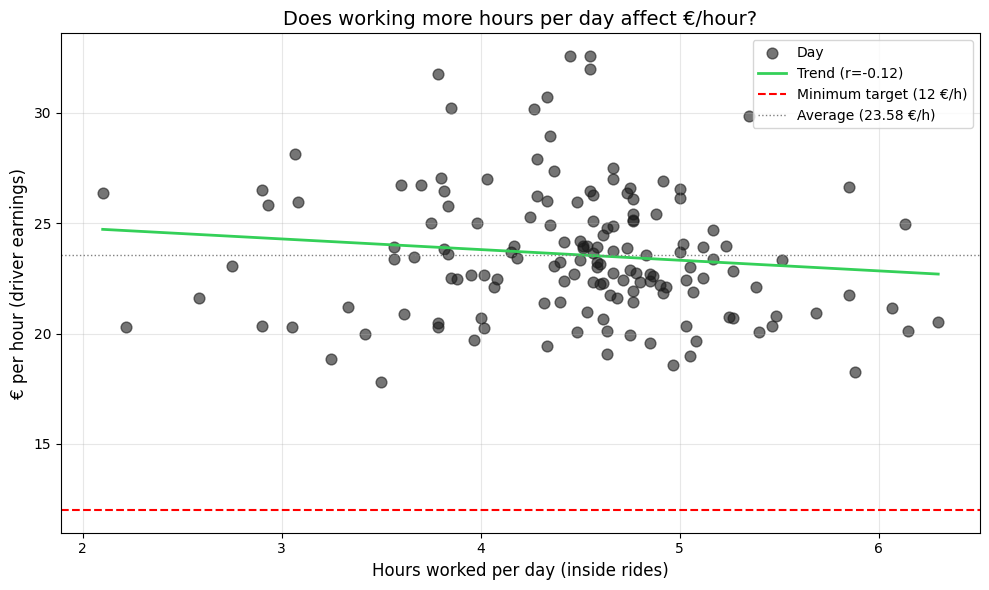


Correlation (r): -0.121
Slope: -0.483 €/hour lost or gained per extra hour worked
P-value: 0.1388 (not statistically significant)


In [15]:
# Scatter plot: hours worked per day vs €/hour earned
# Adding a trend line to show the relationship direction

from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(
    daily["total_hours"], daily["eur_per_hour"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    daily["total_hours"],
    daily["eur_per_hour"],
    color="#1a1a1a", alpha=0.6, s=60, label="Day"
)

x_line = np.linspace(daily["total_hours"].min(), daily["total_hours"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#34d058", linewidth=2, label=f"Trend (r={r_value:.2f})")

ax.axhline(y=12, color="red", linewidth=1.5, linestyle="--", label="Minimum target (12 €/h)")
ax.axhline(y=daily["eur_per_hour"].mean(), color="gray", linewidth=1,
           linestyle=":", label=f"Average ({daily['eur_per_hour'].mean():.2f} €/h)")

ax.set_xlabel("Hours worked per day (inside rides)", fontsize=12)
ax.set_ylabel("€ per hour (driver earnings)", fontsize=12)
ax.set_title("Does working more hours per day affect €/hour?", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/block2_hours_vs_eur_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation (r): {r_value:.3f}")
print(f"Slope: {slope:.3f} €/hour lost or gained per extra hour worked")
print(f"P-value: {p_value:.4f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")

### Block 2 — Analysis of the question 1: Does working more hours per day increase €/hour?

**Result:** Very weak negative correlation (r = -0.121, p = 0.1388)

**Interpretation:**  
Working more hours per day does not significantly affect hourly earnings.
The slight downward trend is not statistically significant (p > 0.05),
meaning the result could easily be due to chance.

**Key insight:**  
€/hour depends more on ride quality (fare per km, ride duration)
than on total hours worked. This is consistent with the driver's
strategy of applying strict acceptance criteria per ride.

**Practical conclusion:**  
There is no evidence that longer working days lead to better or worse
hourly returns. Focus on ride selection, not on extending working hours.

### Question 2 — Do longer rides pay more per km?

**Hypothesis:** Longer rides are more efficient per km than shorter ones.  
**Method:** Pearson correlation between ride distance and €/km earned.

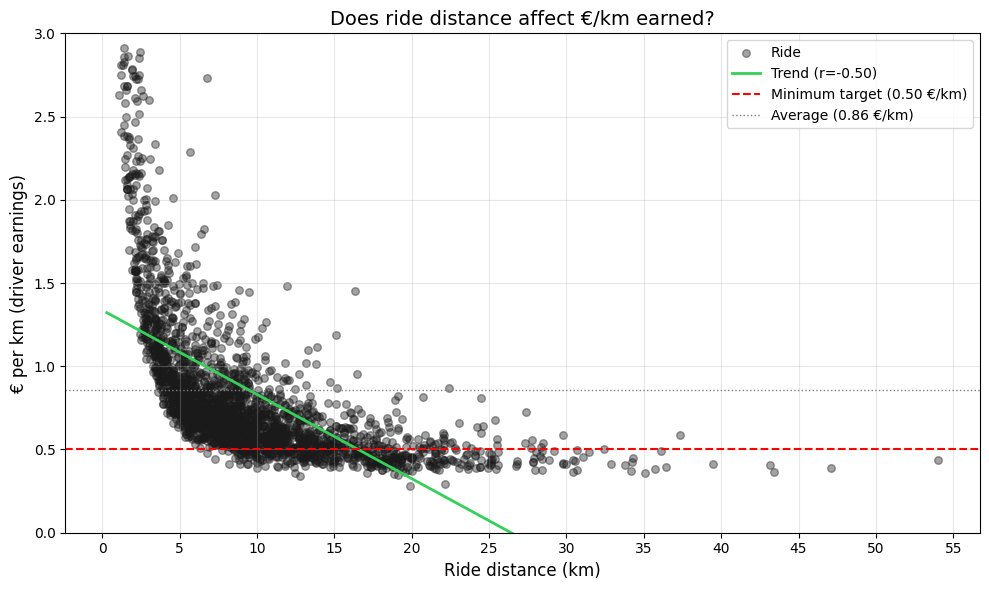


Correlation (r): -0.497
Slope: -0.0506 €/km change per extra km
P-value: 0.000000 (statistically significant)

Average €/km: 0.860
Rides above 0.50 €/km target: 2148 (84.5%)
Rides below 0.50 €/km target: 393 (15.5%)


In [16]:
# Question 2: Is there a relationship between ride distance and €/km earned?
# Longer rides — do they pay more or less per km?

df["eur_per_km"] = df["Driver_Earnings_EUR"] / df["Distance_Km"]

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["Distance_Km"], df["eur_per_km"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["Distance_Km"],
    df["eur_per_km"],
    color="#1a1a1a", alpha=0.4, s=30, label="Ride"
)

x_line = np.linspace(df["Distance_Km"].min(), df["Distance_Km"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#34d058", linewidth=2, label=f"Trend (r={r_value:.2f})")

ax.axhline(y=0.50, color="red", linewidth=1.5, linestyle="--",
           label="Minimum target (0.50 €/km)")
ax.axhline(y=df["eur_per_km"].mean(), color="gray", linewidth=1,
           linestyle=":", label=f"Average ({df['eur_per_km'].mean():.2f} €/km)")

ax.set_xlabel("Ride distance (km)", fontsize=12)
ax.set_ylabel("€ per km (driver earnings)", fontsize=12)
ax.set_title("Does ride distance affect €/km earned?", fontsize=14)
ax.set_ylim(0, 3)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, int(df["Distance_Km"].max()) + 5, 5))

plt.tight_layout()
plt.savefig("../images/block2_distance_vs_eur_per_km.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation (r): {r_value:.3f}")
print(f"Slope: {slope:.4f} €/km change per extra km")
print(f"P-value: {p_value:.6f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")
print(f"\nAverage €/km: {df['eur_per_km'].mean():.3f}")
print(f"Rides above 0.50 €/km target: {(df['eur_per_km'] >= 0.50).sum()} ({(df['eur_per_km'] >= 0.50).mean()*100:.1f}%)")
print(f"Rides below 0.50 €/km target: {(df['eur_per_km'] < 0.50).sum()} ({(df['eur_per_km'] < 0.50).mean()*100:.1f}%)")

### Block 2 — Analysis of the question 2: Does ride distance affect €/km earned?

**Result:** Moderate negative correlation (r = -0.497, p < 0.001)

**Interpretation:**  
Shorter rides consistently yield higher €/km returns. As distance increases,
€/km converges toward the minimum target of 0.50 €/km.

**Key numbers:**
- Average €/km across all rides: 0.860 €
- Rides above 0.50 €/km target: 2,148 (84.5%)
- Rides below 0.50 €/km target: 393 (15.5%)

**Key insight:**  
Short rides are more efficient per km.

### Question 3 — Is the €/hour difference between Uber and Bolt consistent?

**Hypothesis:** One platform systematically pays more per hour than the other.  
**Method:** Mann-Whitney U test (chosen over t-test because earnings are not normally distributed).

UBER vs BOLT — €/hour per ride
--------------------------------------------------
Uber  — Mean: 26.40 | Median: 23.94 | Std: 10.50
Bolt  — Mean: 25.25 | Median: 23.20 | Std: 9.63

Mann-Whitney U test p-value: 0.001866
Result: Statistically significant difference


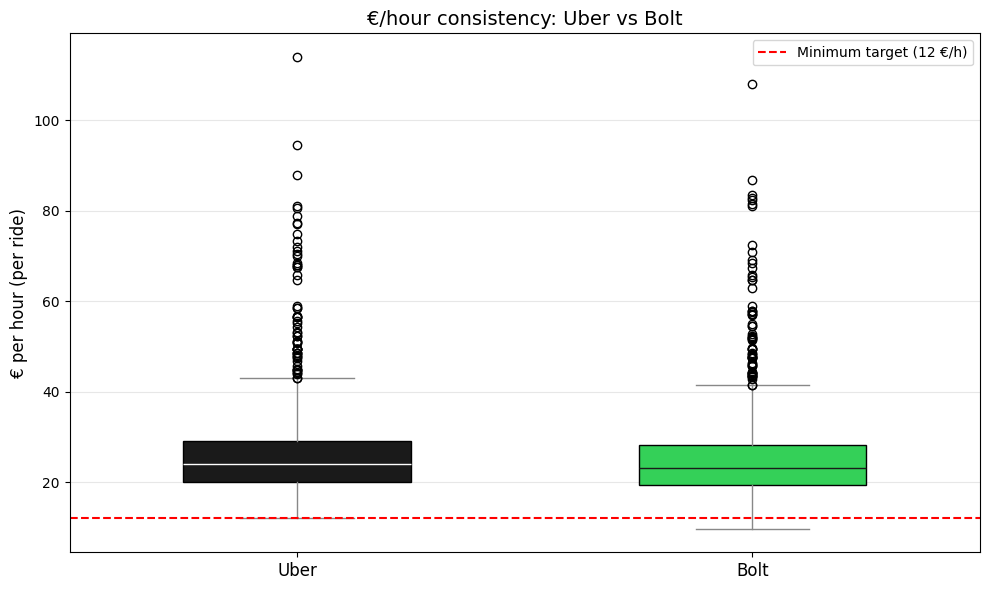

In [17]:
# Question 3: Is the €/hour difference between Uber and Bolt consistent?

df["eur_per_min"] = df["Driver_Earnings_EUR"] / df["Duration_Min"]
df["eur_per_hour_ride"] = df["eur_per_min"] * 60

uber = df[df["Platform"] == "Uber"]["eur_per_hour_ride"]
bolt = df[df["Platform"] == "Bolt"]["eur_per_hour_ride"]

# Statistical comparison
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(uber, bolt, alternative="two-sided")

print("UBER vs BOLT — €/hour per ride")
print("-" * 50)
print(f"Uber  — Mean: {uber.mean():.2f} | Median: {uber.median():.2f} | Std: {uber.std():.2f}")
print(f"Bolt  — Mean: {bolt.mean():.2f} | Median: {bolt.median():.2f} | Std: {bolt.std():.2f}")
print(f"\nMann-Whitney U test p-value: {p_value:.6f}")
print(f"Result: {'Statistically significant difference' if p_value < 0.05 else 'No statistically significant difference'}")

# Box plot
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [uber, bolt]
bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5)

bp["boxes"][0].set_facecolor("#1a1a1a")
bp["boxes"][1].set_facecolor("#34d058")
bp["medians"][0].set_color("white")
bp["medians"][1].set_color("#1a1a1a")

for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color("#888888")

ax.set_xticklabels(["Uber", "Bolt"], fontsize=12)
ax.set_ylabel("€ per hour (per ride)", fontsize=12)
ax.set_title("€/hour consistency: Uber vs Bolt", fontsize=14)
ax.axhline(y=12, color="red", linewidth=1.5, linestyle="--", label="Minimum target (12 €/h)")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()

plt.tight_layout()
plt.savefig("../images/block2_uber_vs_bolt_eur_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 2 — Analysis of the question 3: Is the €/hour difference between Uber and Bolt consistent?

**Result:** Statistically significant difference (p = 0.0019)

**Key numbers:**
- Uber: Mean 26.40 €/h | Median 23.94 €/h | Std 10.50
- Bolt: Mean 25.25 €/h | Median 23.20 €/h | Std 9.63

**Interpretation:**  
The €/hour gap between platforms is statistically significant. Uber pays
a higher average and median €/hour than Bolt.

**Key insight:**  
Bolt shows lower variance (Std 9.63 vs 10.50), meaning its rides are
slightly more predictable in terms of earnings per hour.

**Practical conclusion:**  
Platform choice can be weighed on €/hour with confidence: Uber rides
pay somewhat more per hour on average.

### Question 4 — Does more rides per day lead to higher €/hour?

**Hypothesis:** More rides per day reduces idle time and increases hourly efficiency.  
**Method:** Pearson correlation between daily ride count and daily €/hour.

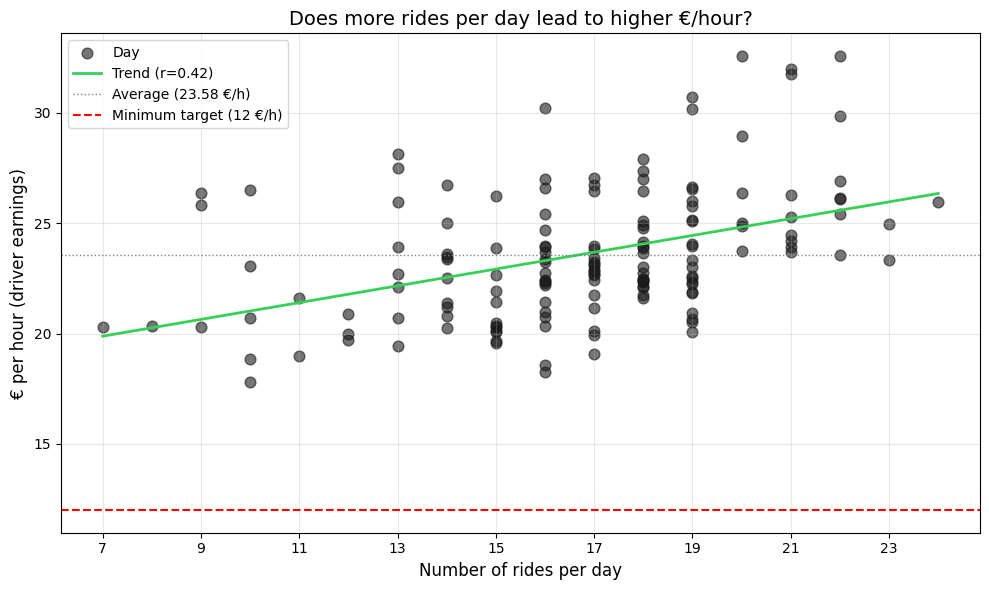


Correlation (r): 0.422
Slope: 0.3805 €/hour change per extra ride
P-value: 0.0000 (statistically significant)

Rides per day stats:
Min: 7 | Max: 24 | Mean: 16.7


In [18]:
# Question 4: Does more rides per day lead to higher €/hour?
# Or is there a saturation point?

slope, intercept, r_value, p_value, std_err = stats.linregress(
    daily["total_rides"], daily["eur_per_hour"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    daily["total_rides"],
    daily["eur_per_hour"],
    color="#1a1a1a", alpha=0.6, s=60, label="Day"
)

x_line = np.linspace(daily["total_rides"].min(), daily["total_rides"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#34d058", linewidth=2, label=f"Trend (r={r_value:.2f})")

ax.axhline(y=daily["eur_per_hour"].mean(), color="gray", linewidth=1,
           linestyle=":", label=f"Average ({daily['eur_per_hour'].mean():.2f} €/h)")
ax.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
           label="Minimum target (12 €/h)")

ax.set_xlabel("Number of rides per day", fontsize=12)
ax.set_ylabel("€ per hour (driver earnings)", fontsize=12)
ax.set_title("Does more rides per day lead to higher €/hour?", fontsize=14)
ax.set_xticks(range(int(daily["total_rides"].min()),
                    int(daily["total_rides"].max()) + 1, 2))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/block2_rides_per_day_vs_eur_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation (r): {r_value:.3f}")
print(f"Slope: {slope:.4f} €/hour change per extra ride")
print(f"P-value: {p_value:.4f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")
print(f"\nRides per day stats:")
print(f"Min: {daily['total_rides'].min()} | Max: {daily['total_rides'].max()} | Mean: {daily['total_rides'].mean():.1f}")

### Block 2 — Analysis of the question 4: Does more rides per day lead to higher €/hour?

**Result:** Moderate positive correlation (r = 0.422, p < 0.001)

**Key numbers:**
- Slope: +0.38 €/hour per extra ride per day
- Rides per day: Min 7 | Mean 16.7 | Max 24
- No saturation point observed within the current range

**Interpretation:**  
More rides per day is associated with higher €/hour — the opposite
of what fatigue-based intuition might suggest. This is explained by
ride density: more rides per day means less idle time between rides,
which increases the efficiency of total hours worked.

**Key insight:**  
Combined with Question 1 (hours worked don't affect €/hour),
this reveals that idle time between rides — not working hours —
is the main driver of inefficiency. Days with more rides are
more profitable not because of longer working hours, but because
of better time utilisation.

**Practical conclusion:**  
Strategies that reduce waiting time between rides (positioning,
peak hours, high-demand zones) are more impactful than simply
working more hours.

### Block 2 — Key Conclusions

| Question | Result | Significant? |
|---|---|---|
| Q1: More hours → higher €/hour? | r = -0.121 | No (p = 0.1388) |
| Q2: Longer rides → higher €/km? | r = -0.497 | Yes (p < 0.001) |
| Q3: Uber vs Bolt €/hour consistent? | p = 0.0019 | Yes — Uber higher |
| Q4: More rides → higher €/hour? | r = 0.422 | Yes (p < 0.001) |

**Overall insight:**  
Hourly earnings are not driven by working longer hours, but by ride density and ride quality.
Short rides yield higher €/km, while more rides per day (less idle time) leads to better €/hour.

---
## Block 3 — Temporal Patterns

This block analyses how earnings and ride volume vary across days of the week,
hours of the day, months and day types (weekday vs weekend).

### Question 5 — Is there a consistent weekly pattern?

**Question:** Does the day of the week reliably predict earnings?  
**Method:** Average daily earnings and €/hour grouped by day of week, with standard deviation to measure consistency.

In [19]:
# BLOCK 3 — TEMPORAL PATTERNS
# Question 5: Is there a consistent weekly pattern in daily earnings?

# Define day order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df["Day_of_Week"] = pd.Categorical(
    pd.to_datetime(df["Date"]).dt.day_name(),
    categories=day_order,
    ordered=True
)

# Calculate €/hour per ride for each ride
df["eur_per_hour_ride"] = (df["Driver_Earnings_EUR"] / df["Duration_Min"]) * 60

# Group by day of week — average earnings and consistency
day_stats = df.groupby("Day_of_Week", observed=True).agg(
    avg_earnings_per_ride=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    std_eur_per_hour=("eur_per_hour_ride", "std"),
    total_rides=("Ride_ID", "count"),
    days_with_data=("Date", "nunique")
).reset_index()

day_stats["avg_daily_earnings"] = (
    df.groupby(["Day_of_Week", "Date"], observed=True)["Driver_Earnings_EUR"]
    .sum()
    .reset_index()
    .groupby("Day_of_Week", observed=True)["Driver_Earnings_EUR"]
    .mean()
    .values
)

print("WEEKLY PATTERN — Average metrics per day of week")
print("-" * 60)
print(day_stats[["Day_of_Week", "avg_daily_earnings",
                  "avg_eur_per_hour", "std_eur_per_hour",
                  "total_rides", "days_with_data"]].to_string(index=False))

WEEKLY PATTERN — Average metrics per day of week
------------------------------------------------------------
Day_of_Week  avg_daily_earnings  avg_eur_per_hour  std_eur_per_hour  total_rides  days_with_data
     Monday          107.782609         24.856384          9.789549          402              23
    Tuesday          100.902857         25.777197         10.783413          351              21
  Wednesday          110.811667         24.317215          8.585044          199              12
   Thursday           98.659091         24.925147          9.179880          361              22
     Friday          115.567600         27.181616         12.022210          426              25
   Saturday          102.724583         25.974187          8.851743          399              24
     Sunday          101.356800         26.547956          9.637877          403              25


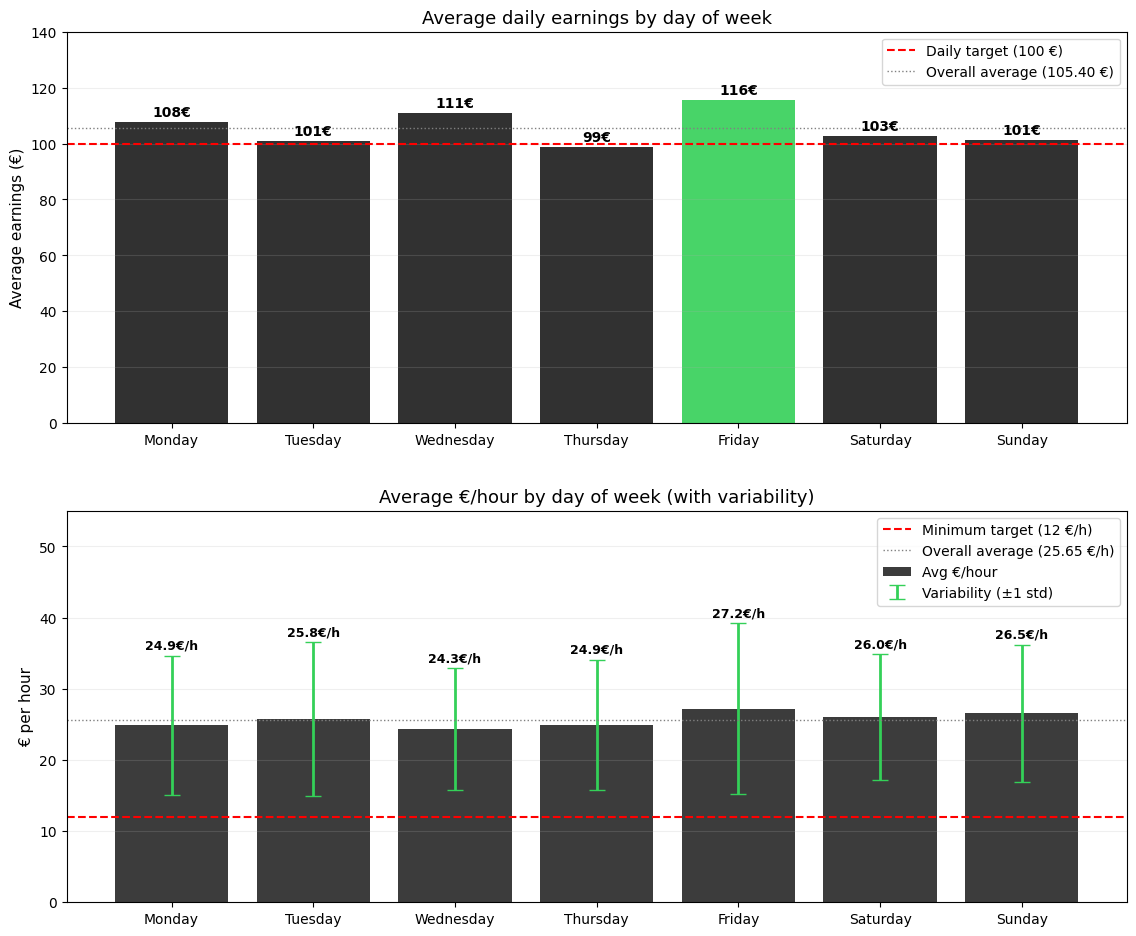

In [20]:
# Weekly pattern — bar chart with consistency bands

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1 — Average daily earnings per day of week
colors = ["#34d058" if e == day_stats["avg_daily_earnings"].max()
          else "#1a1a1a" for e in day_stats["avg_daily_earnings"]]

bars = ax1.bar(day_stats["Day_of_Week"], day_stats["avg_daily_earnings"],
               color=colors, alpha=0.9, edgecolor="none")

ax1.axhline(y=100, color="red", linewidth=1.5, linestyle="--",
            label="Daily target (100 €)")
ax1.axhline(y=day_stats["avg_daily_earnings"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Overall average ({day_stats['avg_daily_earnings'].mean():.2f} €)")

for bar, val in zip(bars, day_stats["avg_daily_earnings"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}€", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_title("Average daily earnings by day of week", fontsize=13)
ax1.set_ylabel("Average earnings (€)", fontsize=11)
ax1.set_ylim(0, 140)
ax1.legend()
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — €/hour with consistency band (mean ± std)
ax2.bar(day_stats["Day_of_Week"], day_stats["avg_eur_per_hour"],
        color="#1a1a1a", alpha=0.85, edgecolor="none", label="Avg €/hour")

ax2.errorbar(day_stats["Day_of_Week"], day_stats["avg_eur_per_hour"],
             yerr=day_stats["std_eur_per_hour"],
             fmt="none", color="#34d058", capsize=6, linewidth=2,
             label="Variability (±1 std)")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.axhline(y=day_stats["avg_eur_per_hour"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Overall average ({day_stats['avg_eur_per_hour'].mean():.2f} €/h)")

for i, (val, std) in enumerate(zip(day_stats["avg_eur_per_hour"],
                                    day_stats["std_eur_per_hour"])):
    ax2.text(i, val + std + 0.5, f"{val:.1f}€/h",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_title("Average €/hour by day of week (with variability)", fontsize=13)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_ylim(0, 55)
ax2.legend()
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block3_weekly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 3 — Analysis of the question 5: Is there a consistent weekly pattern?

**Average daily earnings by day of week:**
| Day | Avg Daily € | Avg €/hour |
|---|---|---|
| Monday | 108 € | 24.9 €/h |
| Tuesday | 101 € | 25.8 €/h |
| Wednesday | 111 € | 24.3 €/h |
| Thursday | 99 € | 24.9 €/h |
| Friday | 116 € ⭐ | 27.2 €/h ⭐ |
| Saturday | 103 € | 26.0 €/h |
| Sunday | 101 € | 26.5 €/h |

**Interpretation:**  
Friday is the best-performing day.

**Key insight:**  
No day represents a genuine risk of falling below the minimum target; all days comfortably exceed the
12 €/hour minimum criterion.

### Question 6 — Which hour of the day generates the most profit?

**Question:** Is there a "golden window" — a time of day that consistently delivers higher earnings?  
**Method:** Total earnings volume and average €/hour calculated per hour, filtered to hours with at least 10 rides.

In [21]:
# Question 6: Which hour of the day generates the most profit?
# Measured by both €/hour efficiency AND total earnings volume

from datetime import datetime

df["Hour"] = pd.to_datetime(df["Start_Time"].astype(str), format="%H:%M:%S").dt.hour

hour_stats = df.groupby("Hour").agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    total_rides=("Ride_ID", "count")
).reset_index()

hour_stats["earnings_per_ride"] = (
    hour_stats["total_earnings"] / hour_stats["total_rides"]
)

print("HOURLY PATTERN — Earnings by hour of day")
print("-" * 60)
print(hour_stats.to_string(index=False))

HOURLY PATTERN — Earnings by hour of day
------------------------------------------------------------
 Hour  total_earnings  avg_eur_per_hour  total_rides  earnings_per_ride
    7            7.33         25.870588            1           7.330000
    8           37.70         26.033380            5           7.540000
    9           93.74         27.783942           13           7.210769
   10           70.34         21.653046            9           7.815556
   11           66.00         21.979356           12           5.500000
   12          319.90         25.510506           40           7.997500
   13         2051.27         25.886898          298           6.883456
   14         2144.40         24.394008          380           5.643158
   15         1678.90         24.206471          292           5.749658
   16         2072.82         27.160679          334           6.206048
   17         2118.24         26.321729          318           6.661132
   18         1769.52         26.6

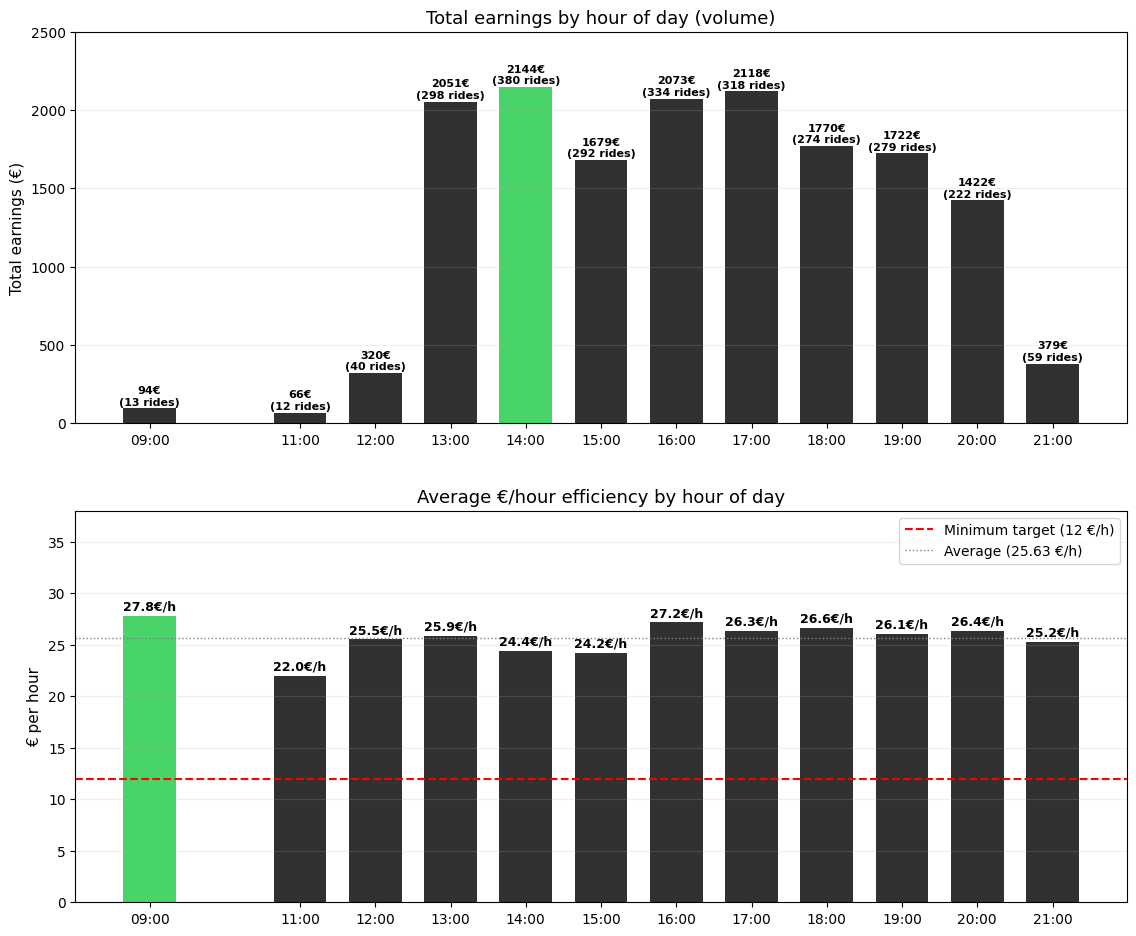

In [22]:
# Hourly pattern — dual chart: total earnings volume + €/hour efficiency

# Filter to relevant hours (at least 10 rides for statistical relevance)
hour_filtered = hour_stats[hour_stats["total_rides"] >= 10].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1 — Total earnings by hour (volume)
colors_vol = ["#34d058" if e == hour_filtered["total_earnings"].max()
              else "#1a1a1a" for e in hour_filtered["total_earnings"]]

bars1 = ax1.bar(hour_filtered["Hour"], hour_filtered["total_earnings"],
                color=colors_vol, alpha=0.9, edgecolor="none", width=0.7)

for bar, val, rides in zip(bars1, hour_filtered["total_earnings"],
                            hour_filtered["total_rides"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{val:.0f}€\n({rides} rides)", ha="center", va="bottom",
             fontsize=8, fontweight="bold")

ax1.set_title("Total earnings by hour of day (volume)", fontsize=13)
ax1.set_ylabel("Total earnings (€)", fontsize=11)
ax1.set_xticks(hour_filtered["Hour"])
ax1.set_xticklabels([f"{h:02d}:00" for h in hour_filtered["Hour"]])
ax1.set_ylim(0, 2500)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Average €/hour by hour (efficiency)
colors_eff = ["#34d058" if e == hour_filtered["avg_eur_per_hour"].max()
              else "#1a1a1a" for e in hour_filtered["avg_eur_per_hour"]]

bars2 = ax2.bar(hour_filtered["Hour"], hour_filtered["avg_eur_per_hour"],
                color=colors_eff, alpha=0.9, edgecolor="none", width=0.7)

for bar, val in zip(bars2, hour_filtered["avg_eur_per_hour"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}€/h", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.axhline(y=hour_filtered["avg_eur_per_hour"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Average ({hour_filtered['avg_eur_per_hour'].mean():.2f} €/h)")

ax2.set_title("Average €/hour efficiency by hour of day", fontsize=13)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_xticks(hour_filtered["Hour"])
ax2.set_xticklabels([f"{h:02d}:00" for h in hour_filtered["Hour"]])
ax2.set_ylim(0, 38)
ax2.legend()
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block3_hourly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 3 — Analysis of the question 6: Which hour of the day generates the most profit?

**Best hours by volume:** 14:00 (2,144€ | 380 rides) and 17:00 (2,118€ | 318 rides)  
**Best hours by efficiency:** 16:00 (27.2 €/h) and 18:00 (26.6 €/h)

**Interpretation:**  
16:00 is the optimal hour for efficiency, and 14:00 leads in total
earnings volume. The period between 16:00 and 18:00 is the "golden
window" where demand and ride value peak together.

**Key insight:**  
The driver's working schedule (12:30–22:00) is well aligned with peak
profitability. Morning hours (before 12:00) show higher €/hour in
isolated cases but with very low ride volume — not enough to draw
reliable conclusions.

**Practical conclusion:**  
Prioritising availability between 16:00 and 18:00 is the single most
impactful time-based decision a TVDE driver can make in Lisbon.

### Question 7 — Is there a trend over time in €/hour earnings?

**Question:** Is the driver becoming more efficient month by month?  
**Method:** Monthly aggregation of €/hour with linear trend line.

In [23]:
# Question 7: Is there a trend over time in €/hour earnings?
# Are earnings improving, declining or stable month by month?

df["Month"] = pd.to_datetime(df["Date"]).dt.to_period("M")
df["Week"] = pd.to_datetime(df["Date"]).dt.to_period("W")

# Monthly aggregation
monthly = df.groupby("Month").agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_duration_min=("Duration_Min", "sum"),
    total_rides=("Ride_ID", "count"),
    working_days=("Date", "nunique")
).reset_index()

monthly["total_hours"] = monthly["total_duration_min"] / 60
monthly["eur_per_hour"] = monthly["total_earnings"] / monthly["total_hours"]
monthly["avg_daily_earnings"] = monthly["total_earnings"] / monthly["working_days"]
monthly["Month_str"] = monthly["Month"].astype(str)

# Weekly aggregation for trend line
weekly = df.groupby("Week").agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_duration_min=("Duration_Min", "sum"),
    total_rides=("Ride_ID", "count")
).reset_index()

weekly["total_hours"] = weekly["total_duration_min"] / 60
weekly["eur_per_hour"] = weekly["total_earnings"] / weekly["total_hours"]
weekly["Week_num"] = range(len(weekly))

print("MONTHLY TREND — Key metrics")
print("-" * 70)
print(monthly[["Month_str", "total_earnings", "eur_per_hour",
               "avg_daily_earnings", "total_rides", "working_days"]].to_string(index=False))

MONTHLY TREND — Key metrics
----------------------------------------------------------------------
Month_str  total_earnings  eur_per_hour  avg_daily_earnings  total_rides  working_days
  2026-03         2664.52     22.045119          102.481538          410            26
  2026-04         2265.98     21.190586           98.520870          346            23
  2026-05         2899.39     23.902638          103.549643          443            28
  2026-06         2984.85     24.573408          110.550000          484            27
  2026-07         2724.16     25.431710          113.506667          439            24
  2026-08         2447.80     23.982364          101.991667          419            24


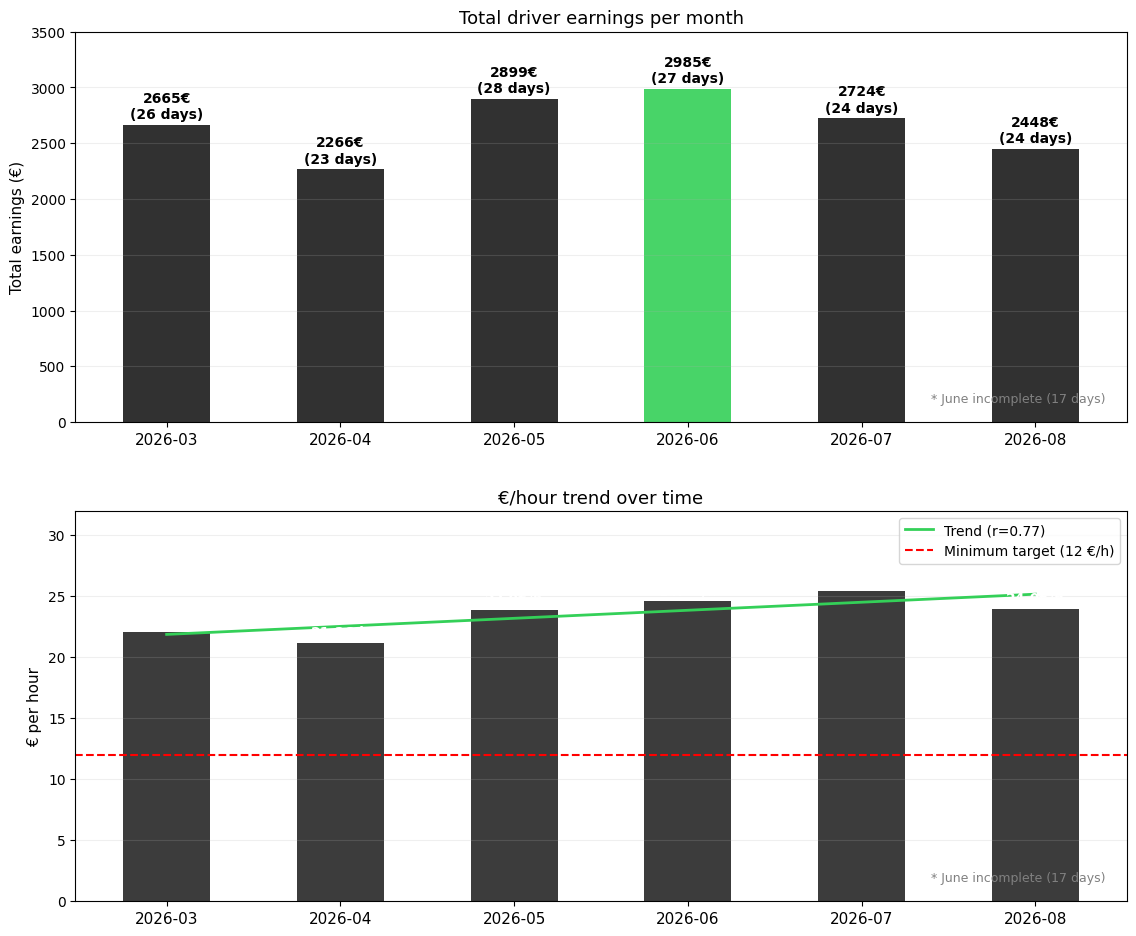


Trend correlation (r): 0.773
Slope: 0.659 €/hour per month
P-value: 0.0713 (not statistically significant


In [24]:
# Monthly trend — dual chart: total earnings + €/hour evolution

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

x = range(len(monthly))
month_labels = monthly["Month_str"].tolist()

# Chart 1 — Total earnings per month
colors_m = ["#34d058" if e == monthly["total_earnings"].max()
            else "#1a1a1a" for e in monthly["total_earnings"]]

bars1 = ax1.bar(x, monthly["total_earnings"], color=colors_m,
                alpha=0.9, edgecolor="none", width=0.5)

for bar, val, days in zip(bars1, monthly["total_earnings"], monthly["working_days"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{val:.0f}€\n({days} days)", ha="center", va="bottom",
             fontsize=10, fontweight="bold")

ax1.set_title("Total driver earnings per month", fontsize=13)
ax1.set_ylabel("Total earnings (€)", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels, fontsize=11)
ax1.set_ylim(0, 3500)
ax1.grid(True, alpha=0.2, axis="y")
ax1.annotate("* June incomplete (17 days)", xy=(0.98, 0.05),
             xycoords="axes fraction", ha="right", fontsize=9, color="gray")

# Chart 2 — €/hour trend over time
ax2.bar(x, monthly["eur_per_hour"], color="#1a1a1a",
        alpha=0.85, edgecolor="none", width=0.5)

# Trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    list(x), monthly["eur_per_hour"].tolist()
)
x_line = np.linspace(min(x), max(x), 100)
y_line = slope * x_line + intercept
ax2.plot(x_line, y_line, color="#34d058", linewidth=2,
         label=f"Trend (r={r_value:.2f})")

for i, val in enumerate(monthly["eur_per_hour"]):
    ax2.text(i, val + 0.3, f"{val:.1f}€/h",
             ha="center", va="bottom", fontsize=10, fontweight="bold",
             color="white")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.set_title("€/hour trend over time", fontsize=13)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(month_labels, fontsize=11)
ax2.set_ylim(0, 32)
ax2.legend()
ax2.grid(True, alpha=0.2, axis="y")
ax2.annotate("* June incomplete (17 days)", xy=(0.98, 0.05),
             xycoords="axes fraction", ha="right", fontsize=9, color="gray")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block3_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTrend correlation (r): {r_value:.3f}")
print(f"Slope: {slope:.3f} €/hour per month")
print(f"P-value: {p_value:.4f} ({'statistically significant' if p_value < 0.05 else 'not statistically significant'}")

### Block 3 — Analysis of the question 7: Is there a trend over time in €/hour earnings?

**Result:** Strong positive correlation, not statistically significant (r = 0.773, p = 0.0713)

**Monthly €/hour progression (March–August 2026):**
| Month | Total Earnings | €/hour | Working Days |
|---|---|---|---|
| March 2026 | 2,665 € | 22.0 €/h | 26 |
| April 2026 | 2,266 € | 21.2 €/h | 23 |
| May 2026 | 2,899 € | 23.9 €/h | 28 |
| June 2026 | 2,985 € | 24.6 €/h | 27 |
| July 2026 | 2,724 € | 25.4 €/h | 24 |
| August 2026 | 2,448 € | 24.0 €/h | 24 |

**Interpretation:**  
The upward trend in €/hour is visible (r = 0.773) but is not
statistically significant at the p < 0.05 threshold (p = 0.0713) —
it's just outside it. August came in below both June and July,
breaking the run of month-over-month gains.

**Key insight:**  
The improvement from March (22.0 €/h) to July (25.4 €/h) suggests real
gains from optimising ride selection and positioning, but August's dip
(24.0 €/h) is a reminder the trend isn't purely linear month to month —
seasonal or one-off factors may be involved.

### Question 8 — Do weekends behave differently from weekdays?

**Question:** Are weekends more or less profitable than working days?  
**Method:** Mann-Whitney U test comparing daily earnings and €/hour between weekdays and weekends.

In [25]:
# Question 8: Do weekends behave differently from weekdays?

from scipy.stats import mannwhitneyu

df["Is_Weekend"] = pd.to_datetime(df["Date"]).dt.dayofweek >= 5
df["Day_Type"] = df["Is_Weekend"].map({True: "Weekend", False: "Weekday"})

# Daily aggregation by day type
daily_type = df.groupby(["Date", "Day_Type"]).agg(
    total_earnings=("Driver_Earnings_EUR", "sum"),
    total_duration_min=("Duration_Min", "sum"),
    total_rides=("Ride_ID", "count")
).reset_index()

daily_type["total_hours"] = daily_type["total_duration_min"] / 60
daily_type["eur_per_hour"] = daily_type["total_earnings"] / daily_type["total_hours"]

weekday = daily_type[daily_type["Day_Type"] == "Weekday"]
weekend = daily_type[daily_type["Day_Type"] == "Weekend"]

# Statistical test
stat, p_earnings = mannwhitneyu(
    weekday["total_earnings"], weekend["total_earnings"], alternative="two-sided"
)
stat, p_eur_hour = mannwhitneyu(
    weekday["eur_per_hour"], weekend["eur_per_hour"], alternative="two-sided"
)

print("WEEKDAY vs WEEKEND — Daily metrics")
print("-" * 60)
print(f"{'Metric':<25} {'Weekday':>12} {'Weekend':>12}")
print("-" * 60)
print(f"{'Days analysed':<25} {len(weekday):>12} {len(weekend):>12}")
print(f"{'Avg daily earnings':<25} {weekday['total_earnings'].mean():>11.2f}€ {weekend['total_earnings'].mean():>11.2f}€")
print(f"{'Median daily earnings':<25} {weekday['total_earnings'].median():>11.2f}€ {weekend['total_earnings'].median():>11.2f}€")
print(f"{'Avg €/hour':<25} {weekday['eur_per_hour'].mean():>11.2f}€ {weekend['eur_per_hour'].mean():>11.2f}€")
print(f"{'Avg rides per day':<25} {weekday['total_rides'].mean():>12.1f} {weekend['total_rides'].mean():>12.1f}")
print("-" * 60)
print(f"\nMann-Whitney p-value (earnings): {p_earnings:.4f} "
      f"({'significant' if p_earnings < 0.05 else 'not significant'})")
print(f"Mann-Whitney p-value (€/hour):   {p_eur_hour:.4f} "
      f"({'significant' if p_eur_hour < 0.05 else 'not significant'})")

WEEKDAY vs WEEKEND — Daily metrics
------------------------------------------------------------
Metric                         Weekday      Weekend
------------------------------------------------------------
Days analysed                      103           49
Avg daily earnings             106.67€      102.03€
Median daily earnings          107.38€      107.85€
Avg €/hour                      23.21€       24.36€
Avg rides per day                 16.9         16.4
------------------------------------------------------------

Mann-Whitney p-value (earnings): 0.5451 (not significant)
Mann-Whitney p-value (€/hour):   0.0064 (significant)


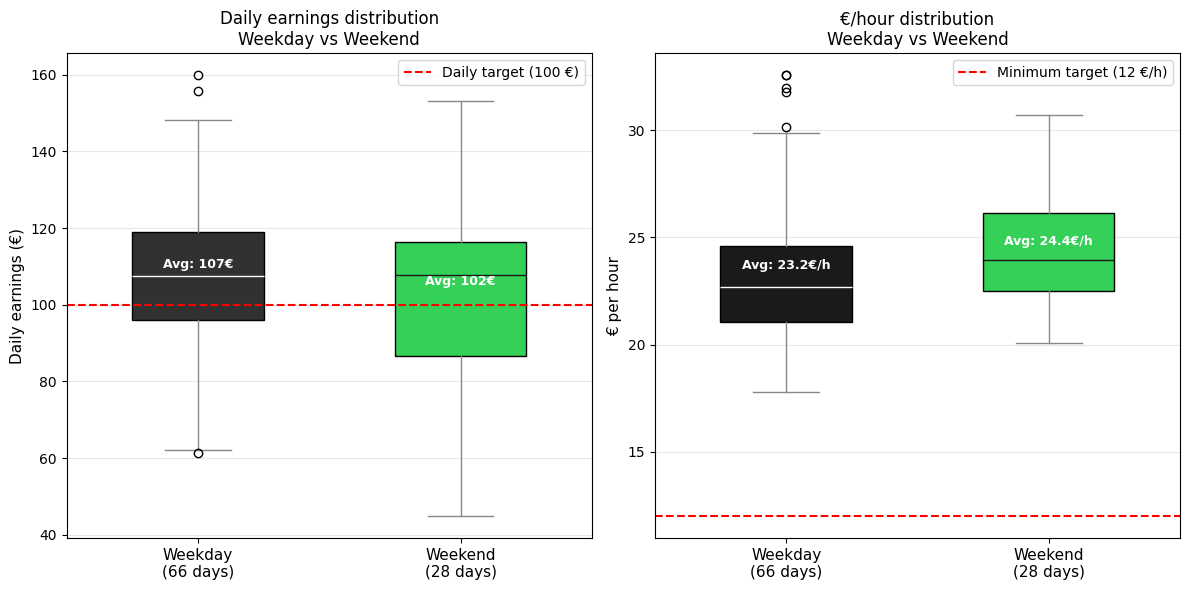

In [26]:
# Weekday vs Weekend — visual comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Chart 1 — Box plot daily earnings
data_earnings = [weekday["total_earnings"], weekend["total_earnings"]]
bp1 = ax1.boxplot(data_earnings, patch_artist=True, widths=0.5)
bp1["boxes"][0].set_facecolor("#323131")
bp1["boxes"][1].set_facecolor("#34d058")
bp1["medians"][0].set_color("white")
bp1["medians"][1].set_color("#1a1a1a")
for element in ["whiskers", "caps", "fliers"]:
    for item in bp1[element]:
        item.set_color("#888888")

ax1.axhline(y=100, color="red", linewidth=1.5, linestyle="--",
            label="Daily target (100 €)")
ax1.set_xticklabels(["Weekday\n(66 days)", "Weekend\n(28 days)"], fontsize=11)
ax1.set_ylabel("Daily earnings (€)", fontsize=11)
ax1.set_title("Daily earnings distribution\nWeekday vs Weekend", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Add mean annotations
for i, (data, color) in enumerate([(weekday["total_earnings"], "white"),
                                    (weekend["total_earnings"], "#1a1a1a")], 1):
    ax1.text(i, data.mean() + 3, f"Avg: {data.mean():.0f}€",
             ha="center", fontsize=9, fontweight="bold", color="white")

# Chart 2 — Box plot €/hour
data_eur = [weekday["eur_per_hour"], weekend["eur_per_hour"]]
bp2 = ax2.boxplot(data_eur, patch_artist=True, widths=0.5)
bp2["boxes"][0].set_facecolor("#1a1a1a")
bp2["boxes"][1].set_facecolor("#34d058")
bp2["medians"][0].set_color("white")
bp2["medians"][1].set_color("#1a1a1a")
for element in ["whiskers", "caps", "fliers"]:
    for item in bp2[element]:
        item.set_color("#888888")

ax2.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.set_xticklabels(["Weekday\n(66 days)", "Weekend\n(28 days)"], fontsize=11)
ax2.set_ylabel("€ per hour", fontsize=11)
ax2.set_title("€/hour distribution\nWeekday vs Weekend", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

for i, (data, color) in enumerate([(weekday["eur_per_hour"], "white"),
                                    (weekend["eur_per_hour"], "#1a1a1a")], 1):
    ax2.text(i, data.mean() + 0.3, f"Avg: {data.mean():.1f}€/h",
             ha="center", fontsize=9, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig("../images/block3_weekday_vs_weekend.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 3 — Analysis of the question 8: Do weekends behave differently from weekdays?

**Result:** Earnings not significant (p = 0.5451); €/hour significant (p = 0.0064)

**Key numbers:**
| Metric | Weekday | Weekend |
|---|---|---|
| Days analysed | 103 | 49 |
| Avg daily earnings | 106.67 € | 102.03 € |
| Avg €/hour | 23.21 €/h | 24.36 €/h |
| Avg rides per day | 16.9 | 16.4 |

**Interpretation:**  
Weekdays generate slightly higher total daily earnings due to a higher
number of trips, while weekends offer better efficiency in terms of
€/hour.

**Key insight:**  
Weekends are more efficient on an hourly basis, even though they
generate a lower total daily volume. Weekdays hold the advantage in
gross earnings due to the higher volume of trips.

---
## Block 4 — Ride Profile

This block builds a portrait of the typical ride and identifies which ride
characteristics are associated with higher earnings efficiency.

### Question 9 — What is the real distribution of distances and fares?

**Question:** Is the average ride value representative, or do outliers distort it?  
**Method:** Histograms for distance, duration, driver earnings and €/km — comparing mean vs median.

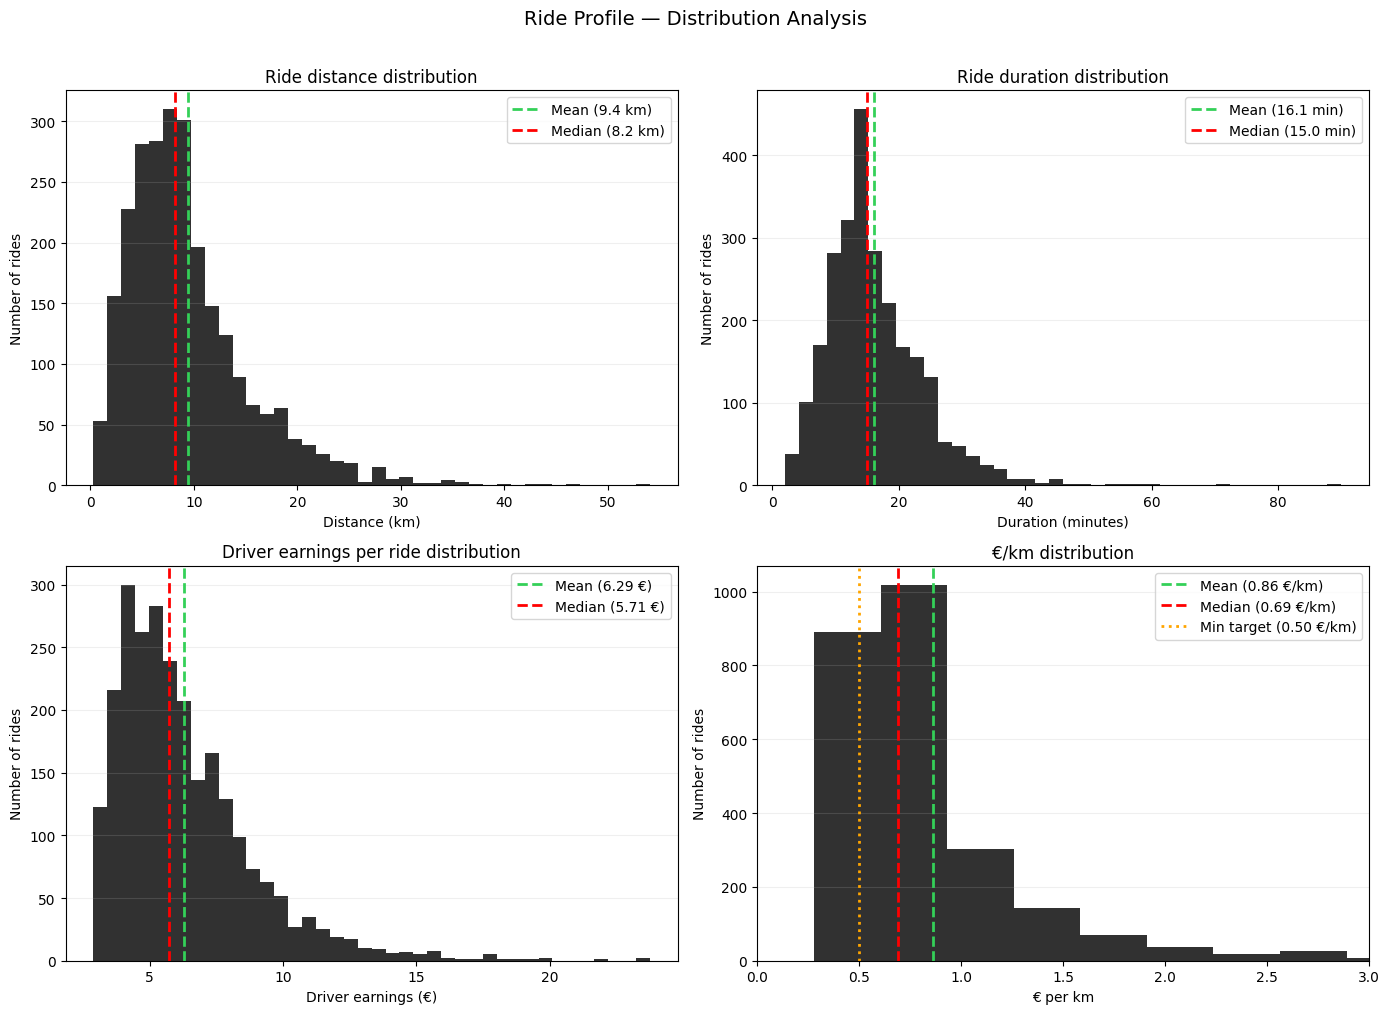

DISTRIBUTION SUMMARY
------------------------------------------------------------

Distance (km)
  Mean:   9.43 | Median: 8.20 | Std: 5.99
  Min:    0.30 | Max:    54.04
  25th%:  5.30 | 75th%:  11.80

Duration (min)
  Mean:   16.05 | Median: 15.00 | Std: 7.55
  Min:    2.00 | Max:    90.00
  25th%:  11.00 | 75th%:  20.00

Driver earnings (€)
  Mean:   6.29 | Median: 5.71 | Std: 2.56
  Min:    2.89 | Max:    23.75
  25th%:  4.45 | 75th%:  7.45

€/km
  Mean:   0.86 | Median: 0.69 | Std: 0.61
  Min:    0.28 | Max:    13.33
  25th%:  0.55 | 75th%:  0.93


In [27]:
# BLOCK 4 — RIDE PROFILE
# Question 9: What is the real distribution of distances and fares?
# Is the average representative or misleading?

import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Distance distribution
axes[0,0].hist(df["Distance_Km"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[0,0].axvline(df["Distance_Km"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['Distance_Km'].mean():.1f} km)")
axes[0,0].axvline(df["Distance_Km"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['Distance_Km'].median():.1f} km)")
axes[0,0].set_title("Ride distance distribution", fontsize=12)
axes[0,0].set_xlabel("Distance (km)", fontsize=10)
axes[0,0].set_ylabel("Number of rides", fontsize=10)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.2, axis="y")

# Chart 2 — Duration distribution
axes[0,1].hist(df["Duration_Min"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[0,1].axvline(df["Duration_Min"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['Duration_Min'].mean():.1f} min)")
axes[0,1].axvline(df["Duration_Min"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['Duration_Min'].median():.1f} min)")
axes[0,1].set_title("Ride duration distribution", fontsize=12)
axes[0,1].set_xlabel("Duration (minutes)", fontsize=10)
axes[0,1].set_ylabel("Number of rides", fontsize=10)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.2, axis="y")

# Chart 3 — Driver earnings distribution
axes[1,0].hist(df["Driver_Earnings_EUR"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[1,0].axvline(df["Driver_Earnings_EUR"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['Driver_Earnings_EUR'].mean():.2f} €)")
axes[1,0].axvline(df["Driver_Earnings_EUR"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['Driver_Earnings_EUR'].median():.2f} €)")
axes[1,0].set_title("Driver earnings per ride distribution", fontsize=12)
axes[1,0].set_xlabel("Driver earnings (€)", fontsize=10)
axes[1,0].set_ylabel("Number of rides", fontsize=10)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.2, axis="y")

# Chart 4 — €/km distribution
axes[1,1].hist(df["eur_per_km"], bins=40, color="#1a1a1a",
               edgecolor="none", alpha=0.9)
axes[1,1].axvline(df["eur_per_km"].mean(), color="#34d058",
                  linewidth=2, linestyle="--",
                  label=f"Mean ({df['eur_per_km'].mean():.2f} €/km)")
axes[1,1].axvline(df["eur_per_km"].median(), color="red",
                  linewidth=2, linestyle="--",
                  label=f"Median ({df['eur_per_km'].median():.2f} €/km)")
axes[1,1].axvline(0.50, color="orange", linewidth=2, linestyle=":",
                  label="Min target (0.50 €/km)")
axes[1,1].set_title("€/km distribution", fontsize=12)
axes[1,1].set_xlabel("€ per km", fontsize=10)
axes[1,1].set_ylabel("Number of rides", fontsize=10)
axes[1,1].set_xlim(0, 3)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.2, axis="y")

plt.suptitle("Ride Profile — Distribution Analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../images/block4_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
print("DISTRIBUTION SUMMARY")
print("-" * 60)
for col, label in [
    ("Distance_Km", "Distance (km)"),
    ("Duration_Min", "Duration (min)"),
    ("Driver_Earnings_EUR", "Driver earnings (€)"),
    ("eur_per_km", "€/km")
]:
    print(f"\n{label}")
    print(f"  Mean:   {df[col].mean():.2f} | Median: {df[col].median():.2f} | Std: {df[col].std():.2f}")
    print(f"  Min:    {df[col].min():.2f} | Max:    {df[col].max():.2f}")
    print(f"  25th%:  {df[col].quantile(0.25):.2f} | 75th%:  {df[col].quantile(0.75):.2f}")

### Block 4 — Analysis of the question 9: What is the real distribution of distances and fares?

**The typical ride profile (median values):**
- Distance: 8.2 km
- Duration: 15 minutes
- Driver earnings: 5.71 €
- €/km: 0.69 €/km

**Interpretation:**  
All four distributions are right-skewed — the mean is consistently
higher than the median, meaning a small number of long, high-value
rides pull the average up. The median is the more honest
representation of the typical ride.

**Key insight:**  
75% of all trips are shorter than 11.8 km and generate less than
€7.45. The median €/km (0.69) comfortably exceeds the minimum target
of €0.50/km, confirming the effectiveness of the acceptance criteria.

### Question 10 — Is there an optimal ride distance?

**Question:** Which distance bracket delivers the best balance of €/km and €/hour?  
**Method:** Rides grouped into 7 distance brackets — analysed by €/km, €/hour and volume.

In [28]:
# Question 10: Is there an optimal ride distance that maximises €/km?
# Grouping rides into distance brackets to find the sweet spot

# Create distance brackets
bins = [0, 3, 5, 8, 12, 18, 25, 55]
labels = ["0-3km", "3-5km", "5-8km", "8-12km", "12-18km", "18-25km", "25km+"]

df["Distance_Bracket"] = pd.cut(df["Distance_Km"], bins=bins, labels=labels)

bracket_stats = df.groupby("Distance_Bracket", observed=True).agg(
    total_rides=("Ride_ID", "count"),
    avg_eur_per_km=("eur_per_km", "mean"),
    median_eur_per_km=("eur_per_km", "median"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_duration=("Duration_Min", "mean")
).reset_index()

bracket_stats["pct_rides"] = (bracket_stats["total_rides"] /
                               bracket_stats["total_rides"].sum() * 100)

print("DISTANCE BRACKETS — Performance metrics")
print("-" * 80)
print(bracket_stats[["Distance_Bracket", "total_rides", "pct_rides",
                      "avg_eur_per_km", "avg_eur_per_hour",
                      "avg_earnings", "avg_duration"]].to_string(index=False))

DISTANCE BRACKETS — Performance metrics
--------------------------------------------------------------------------------
Distance_Bracket  total_rides  pct_rides  avg_eur_per_km  avg_eur_per_hour  avg_earnings  avg_duration
           0-3km          215   8.461236        2.222756         42.868612      4.212093      6.748837
           3-5km          351  13.813459        1.109472         27.734059      4.450598     10.247863
           5-8km          663  26.092090        0.803967         24.078824      5.190709     13.550528
          8-12km          699  27.508855        0.663745         22.958924      6.406652     17.474964
         12-18km          376  14.797324        0.556703         23.279766      8.043537     21.367021
         18-25km          177   6.965762        0.478628         24.326223      9.882316     25.192090
           25km+           60   2.361275        0.454008         24.936236     13.761833     34.083333


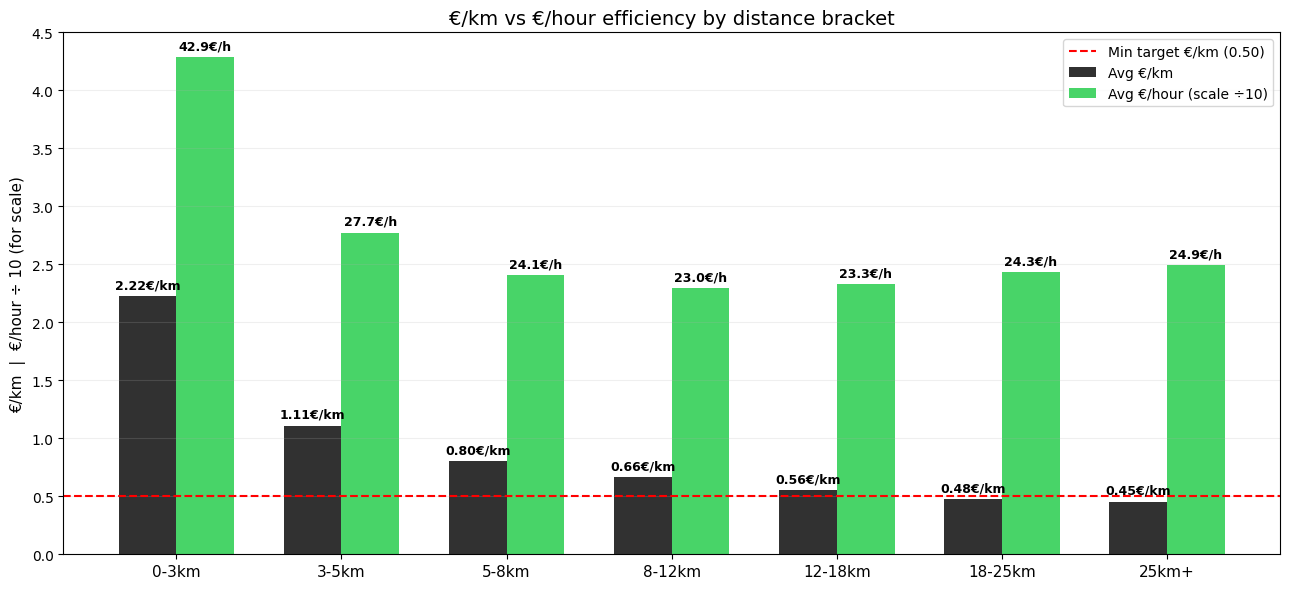

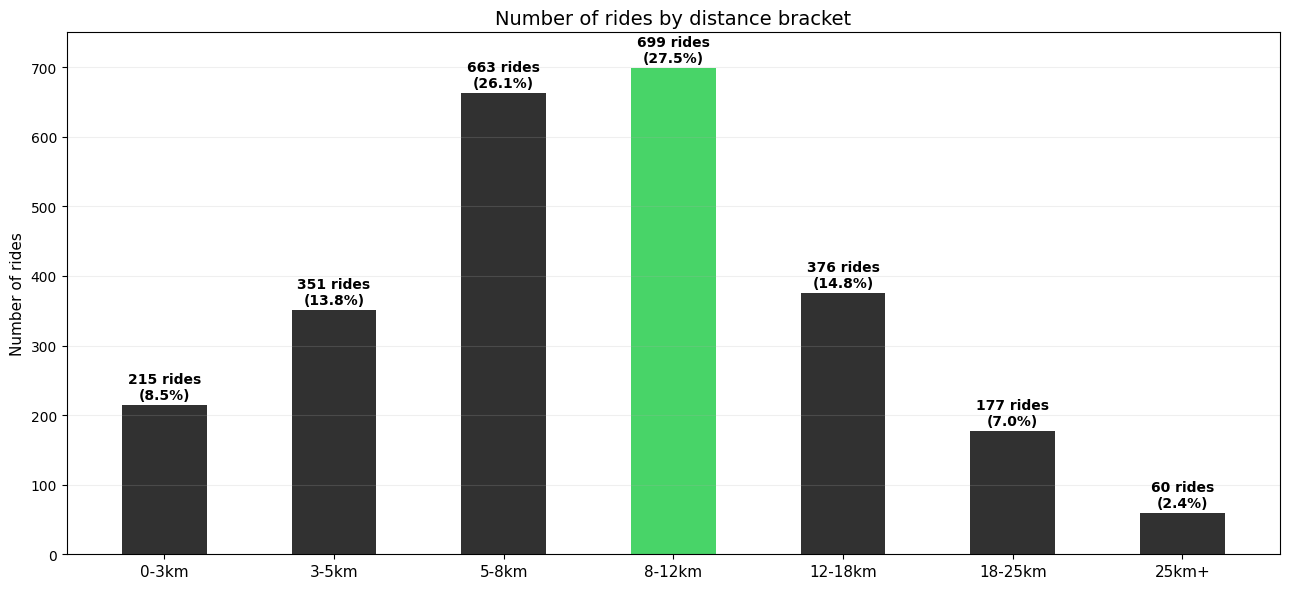

In [29]:
# Distance bracket analysis — two separate clean charts

fig, ax1 = plt.subplots(figsize=(13, 6))

x = range(len(bracket_stats))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], bracket_stats["avg_eur_per_km"],
                width=width, color="#1a1a1a", alpha=0.9, label="Avg €/km")
bars2 = ax1.bar([i + width/2 for i in x], bracket_stats["avg_eur_per_hour"] / 10,
                width=width, color="#34d058", alpha=0.9,
                label="Avg €/hour (scale ÷10)")

ax1.axhline(y=0.50, color="red", linewidth=1.5, linestyle="--",
            label="Min target €/km (0.50)")

for bar, val in zip(bars1, bracket_stats["avg_eur_per_km"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f"{val:.2f}€/km", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

for bar, val in zip(bars2, bracket_stats["avg_eur_per_hour"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f"{val:.1f}€/h", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax1.set_title("€/km vs €/hour efficiency by distance bracket", fontsize=14)
ax1.set_ylabel("€/km  |  €/hour ÷ 10 (for scale)", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(bracket_stats["Distance_Bracket"], fontsize=11)
ax1.set_ylim(0, 4.5)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../images/block4_bracket_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 2 — Volume
fig, ax2 = plt.subplots(figsize=(13, 6))

colors_vol = ["#34d058" if v == bracket_stats["total_rides"].max()
              else "#1a1a1a" for v in bracket_stats["total_rides"]]

bars3 = ax2.bar(x, bracket_stats["total_rides"], color=colors_vol,
                alpha=0.9, edgecolor="none", width=0.5)

for bar, rides, pct in zip(bars3, bracket_stats["total_rides"],
                            bracket_stats["pct_rides"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f"{rides} rides\n({pct:.1f}%)", ha="center", va="bottom",
             fontsize=10, fontweight="bold")

ax2.set_title("Number of rides by distance bracket", fontsize=14)
ax2.set_ylabel("Number of rides", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(bracket_stats["Distance_Bracket"], fontsize=11)
ax2.set_ylim(0, 750)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../images/block4_bracket_volume.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 4 — Analysis of the question 10: Is there an optimal ride distance?

**Efficiency by distance bracket:**
| Distance | Avg €/km | Avg €/hour | Rides | % of total |
|---|---|---|---|---|
| 0–3 km | 2.22 €/km | 42.9 €/h | 215 | 8.5% |
| 3–5 km | 1.11 €/km | 27.7 €/h | 351 | 13.8% |
| 5–8 km | 0.80 €/km | 24.1 €/h | 663 | 26.1% |
| 8–12 km | 0.66 €/km | 23.0 €/h | 699 | 27.5% |
| 12–18 km | 0.56 €/km | 23.3 €/h | 376 | 14.8% |
| 18–25 km | 0.48 €/km | 24.3 €/h | 177 | 7.0% |
| 25+ km | 0.45 €/km | 24.9 €/h | 60 | 2.4% |

**Interpretation:**  
Short rides (0–3 km) are the most efficient per km (2.22 €/km) and per
hour (42.9 €/h), though they represent only a small share of total
rides (8.5%). Beyond 5 km, €/hour stabilises between 23–25 €/h
regardless of distance, while €/km continues to decline.

**Key insight:**  
Rides above 18 km fall below the 0.50 €/km minimum target, but their
€/hour remains competitive (24+ €/h).

**Practical conclusion:**  
The 5–12 km bracket is the optimal balance — it accounts for 53.6% of
all rides, maintains €/km above the minimum target, and delivers
consistent €/hour returns.

### Question 11 — What is the profile of the most frequent ride?

**Question:** What does a typical TVDE ride in Lisbon look like?  
**Method:** Median values for all key metrics, plus breakdown by service category.

In [30]:
# Question 11: What is the profile of the most frequent ride?
# Building a "typical ride" portrait using median values and mode

from scipy import stats as scipy_stats

# Overall typical ride
print("THE TYPICAL RIDE — Portrait")
print("=" * 55)
print(f"  Platform:          {df['Platform'].mode()[0]}")
print(f"  Category:          {df['Category'].mode()[0]}")
print(f"  Day of week:       {df['Day_of_Week'].mode()[0]}")
print(f"  Start hour:        {df['Hour'].mode()[0]:02d}:00")
print(f"  Distance:          {df['Distance_Km'].median():.1f} km")
print(f"  Duration:          {df['Duration_Min'].median():.0f} min")
print(f"  Driver earnings:   {df['Driver_Earnings_EUR'].median():.2f} €")
print(f"  €/km:              {df['eur_per_km'].median():.2f} €/km")
print(f"  €/hour:            {df['eur_per_hour_ride'].median():.2f} €/h")
print("=" * 55)

# Category breakdown
print("\nRIDES BY CATEGORY")
print("-" * 55)
cat_stats = df.groupby("Category").agg(
    total_rides=("Ride_ID", "count"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_km=("eur_per_km", "mean"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_distance=("Distance_Km", "mean")
).reset_index()
cat_stats["pct"] = cat_stats["total_rides"] / cat_stats["total_rides"].sum() * 100
cat_stats = cat_stats.sort_values("total_rides", ascending=False)
print(cat_stats[["Category", "total_rides", "pct",
                 "avg_earnings", "avg_eur_per_km",
                 "avg_eur_per_hour", "avg_distance"]].to_string(index=False))

THE TYPICAL RIDE — Portrait
  Platform:          Bolt
  Category:          Uber X
  Day of week:       Friday
  Start hour:        14:00
  Distance:          8.2 km
  Duration:          15 min
  Driver earnings:   5.71 €
  €/km:              0.69 €/km
  €/hour:            23.57 €/h

RIDES BY CATEGORY
-------------------------------------------------------
       Category  total_rides       pct  avg_earnings  avg_eur_per_km  avg_eur_per_hour  avg_distance
         Uber X          985 38.764266      6.383249        0.771883         25.319260     10.404772
        Economy          661 26.013381      6.132632        0.811891         24.182572      9.831301
           Bolt          609 23.966942      6.323793        0.971446         26.409806      8.207225
Uber X Priority          252  9.917355      5.943214        1.067866         30.062005      7.090794
          Share           27  1.062574      9.303333        0.803659         27.499828     13.094444
        Courier            5  0.1967

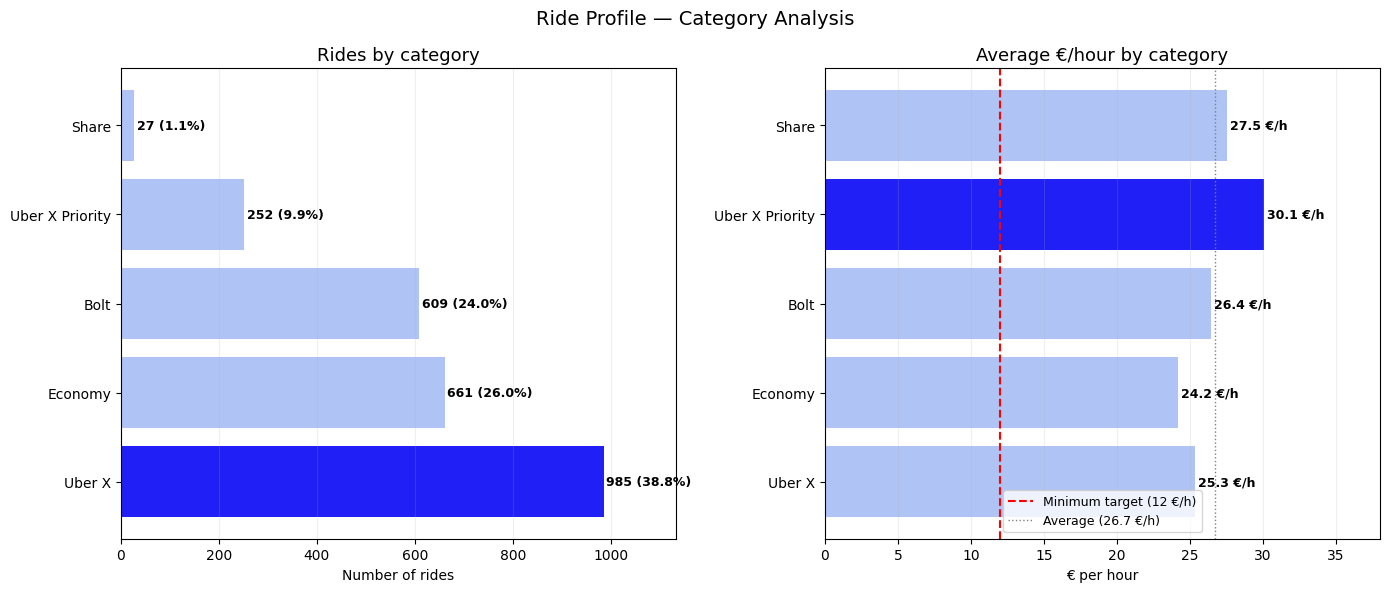

In [31]:
# Ride profile — category performance chart
# Filter to main categories only (>10 rides)

cat_main = cat_stats[cat_stats["total_rides"] > 10].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Volume by category
colors_cat = ["#0606f6" if v == cat_main["total_rides"].max()
              else "#a6bdf4" for v in cat_main["total_rides"]]

bars1 = ax1.barh(cat_main["Category"], cat_main["total_rides"],
                 color=colors_cat, alpha=0.9, edgecolor="none")

for bar, rides, pct in zip(bars1, cat_main["total_rides"], cat_main["pct"]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{rides} ({pct:.1f}%)", va="center", fontsize=9, fontweight="bold")

ax1.set_title("Rides by category", fontsize=13)
ax1.set_xlabel("Number of rides", fontsize=10)
ax1.set_xlim(0, cat_main["total_rides"].max() * 1.15)
ax1.grid(True, alpha=0.2, axis="x")

# Chart 2 — €/hour by category
colors_eff = ["#0606f6" if v == cat_main["avg_eur_per_hour"].max()
              else "#a6bdf4" for v in cat_main["avg_eur_per_hour"]]

bars2 = ax2.barh(cat_main["Category"], cat_main["avg_eur_per_hour"],
                 color=colors_eff, alpha=0.9, edgecolor="none")

for bar, val in zip(bars2, cat_main["avg_eur_per_hour"]):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f} €/h", va="center", fontsize=9, fontweight="bold")

ax2.axvline(x=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax2.axvline(x=cat_main["avg_eur_per_hour"].mean(), color="gray",
            linewidth=1, linestyle=":",
            label=f"Average ({cat_main['avg_eur_per_hour'].mean():.1f} €/h)")

ax2.set_title("Average €/hour by category", fontsize=13)
ax2.set_xlabel("€ per hour", fontsize=10)
ax2.set_xlim(0, 38)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis="x")

plt.suptitle("Ride Profile — Category Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("../images/block4_category_profile.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 4 — Analysis of the question 11: What is the profile of the most frequent ride?

**The typical ride (median values):**
| Metric | Value |
|---|---|
| Platform | Bolt (most common single value) |
| Category | Uber X |
| Day | Friday |
| Start hour | 14:00 |
| Distance | 8.2 km |
| Duration | 15 min |
| Driver earnings | 5.71 € |
| €/km | 0.69 €/km |
| €/hour | 23.57 €/h |

**Category performance (all categories):**
| Category | Rides | % | Avg €/h |
|---|---|---|---|
| Uber X | 985 | 38.8% | 25.3 €/h |
| Economy | 661 | 26.0% | 24.2 €/h |
| Bolt | 609 | 24.0% | 26.4 €/h |
| Uber X Priority | 252 | 9.9% | 30.1 €/h |
| Share | 27 | 1.1% | 27.5 €/h |
| Courier | 5 | 0.2% | 23.9 €/h |

**Key insight:**  
Uber X Priority is the most efficient category (30.1 €/h) despite
lower volume.

---
## Block 5 — Acceptance Criteria & Targets

This block tests the driver's ride acceptance strategy against real data.
The criteria are: minimum 0.50 €/km or minimum 12 €/hour. Example:  A €6 ride must be 12 km long and take 30 minutes.

It also evaluates how consistently the daily (100€ gross) and weekly (500€ net) targets are met.

### Question 12 — What % of rides meet the acceptance criteria?

**Criteria:** Driver_Earnings ≥ 0.50 €/km or ≥ 12 €/hour.  

In [32]:
# BLOCK 5 — ACCEPTANCE CRITERIA ANALYSIS
# Question 12: What % of rides meet the acceptance criteria?
# Criteria: minimum 0.50 €/km or minimum 12 €/hour

# Apply acceptance criteria
df["meets_eur_per_km"] = df["eur_per_km"] >= 0.50
df["meets_eur_per_hour"] = df["eur_per_hour_ride"] >= 12
df["meets_both"] = df["meets_eur_per_km"] & df["meets_eur_per_hour"]

# Classify each ride
def classify_ride(row):
    if row["meets_both"]:
        return "Meets both criteria"
    elif row["meets_eur_per_km"] and not row["meets_eur_per_hour"]:
        return "Only €/km met"
    elif row["meets_eur_per_hour"] and not row["meets_eur_per_km"]:
        return "Only €/hour met"
    else:
        return "Neither met"

df["criteria_status"] = df.apply(classify_ride, axis=1)

# Summary
total = len(df)
print("ACCEPTANCE CRITERIA — Summary")
print("=" * 55)
print(f"Minimum €/km  (≥ 0.50):  {df['meets_eur_per_km'].sum():>5} rides "
      f"({df['meets_eur_per_km'].mean()*100:.1f}%)")
print(f"Minimum €/hour (≥ 12):   {df['meets_eur_per_hour'].sum():>5} rides "
      f"({df['meets_eur_per_hour'].mean()*100:.1f}%)")
print(f"Both criteria met:        {df['meets_both'].sum():>5} rides "
      f"({df['meets_both'].mean()*100:.1f}%)")
print(f"Neither criteria met:     "
      f"{(~df['meets_eur_per_km'] & ~df['meets_eur_per_hour']).sum():>5} rides "
      f"({(~df['meets_eur_per_km'] & ~df['meets_eur_per_hour']).mean()*100:.1f}%)")
print("=" * 55)

print("\nBY PLATFORM")
print("-" * 55)
for platform in ["Uber", "Bolt"]:
    sub = df[df["Platform"] == platform]
    print(f"\n{platform} ({len(sub)} rides):")
    print(f"  Both criteria met:  {sub['meets_both'].sum()} "
          f"({sub['meets_both'].mean()*100:.1f}%)")
    print(f"  Only €/km met:      "
          f"{(sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).sum()} "
          f"({(sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).mean()*100:.1f}%)")
    print(f"  Only €/hour met:    "
          f"{(~sub['meets_eur_per_km'] & sub['meets_eur_per_hour']).sum()} "
          f"({(~sub['meets_eur_per_km'] & sub['meets_eur_per_hour']).mean()*100:.1f}%)")
    print(f"  Neither met:        "
          f"{(~sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).sum()} "
          f"({(~sub['meets_eur_per_km'] & ~sub['meets_eur_per_hour']).mean()*100:.1f}%)")

ACCEPTANCE CRITERIA — Summary
Minimum €/km  (≥ 0.50):   2148 rides (84.5%)
Minimum €/hour (≥ 12):    2535 rides (99.8%)
Both criteria met:         2143 rides (84.3%)
Neither criteria met:         1 rides (0.0%)

BY PLATFORM
-------------------------------------------------------

Uber (1098 rides):
  Both criteria met:  885 (80.6%)
  Only €/km met:      0 (0.0%)
  Only €/hour met:    213 (19.4%)
  Neither met:        0 (0.0%)

Bolt (1271 rides):
  Both criteria met:  1121 (88.2%)
  Only €/km met:      5 (0.4%)
  Only €/hour met:    144 (11.3%)
  Neither met:        1 (0.1%)


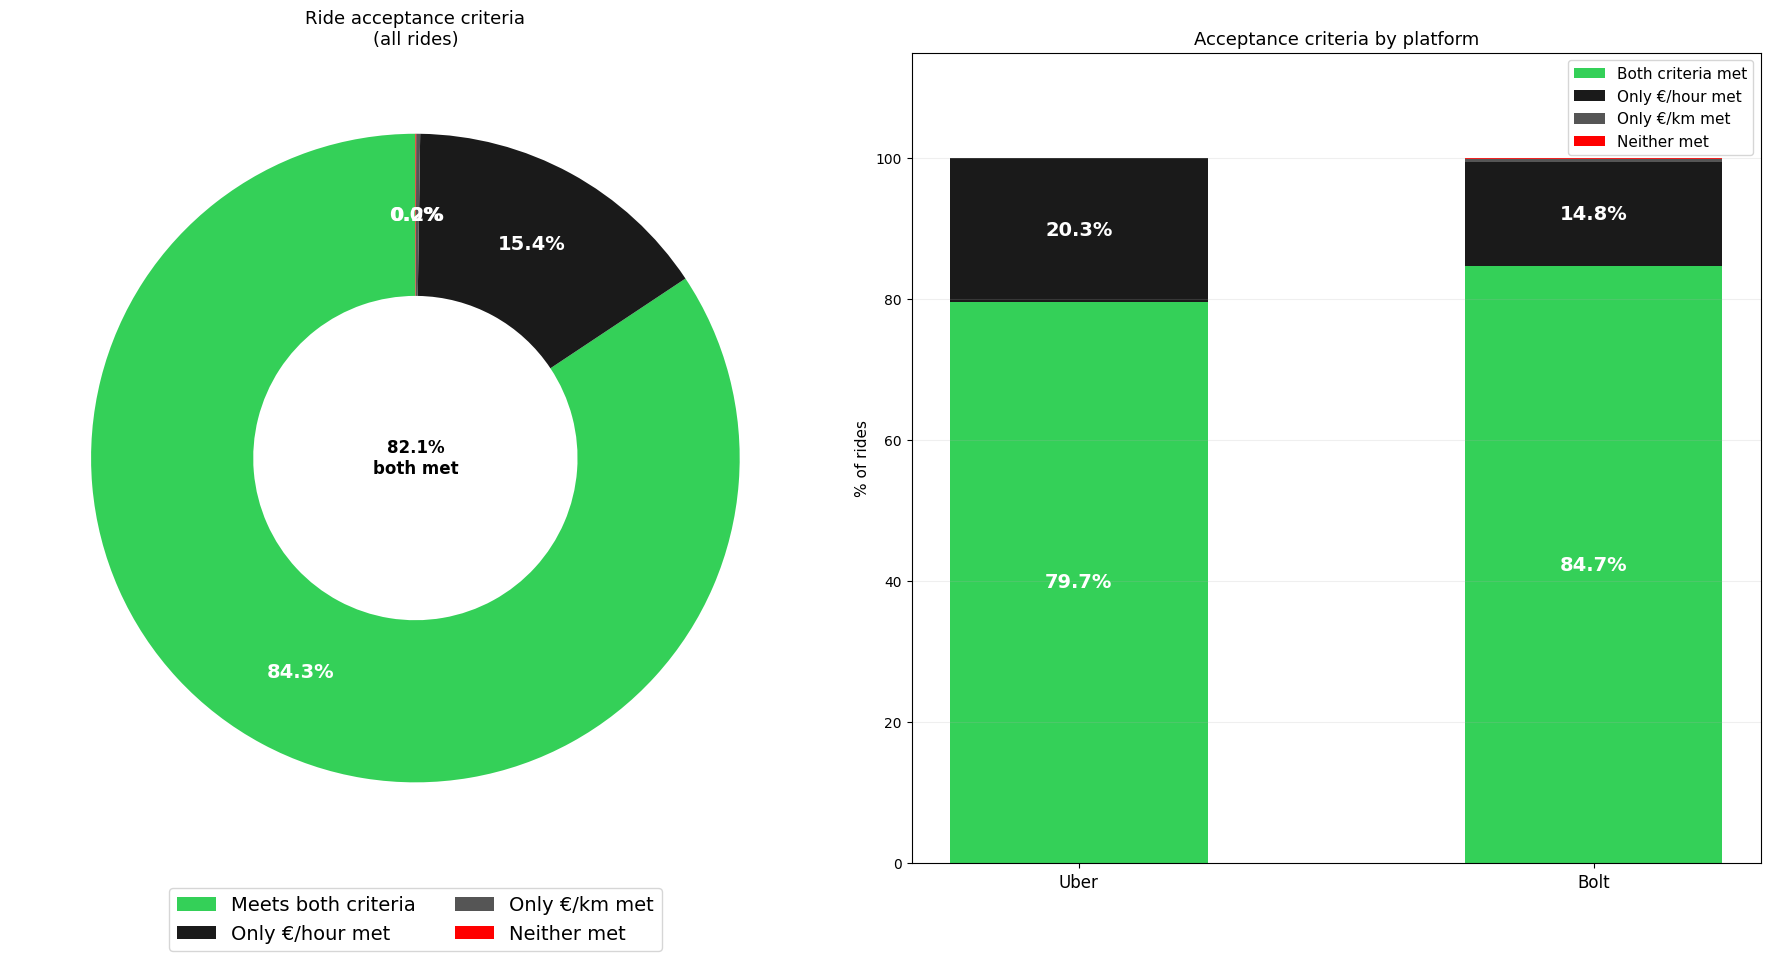

In [33]:
# Acceptance criteria — visual summary

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

# Chart 1 — Overall criteria breakdown (donut)
criteria_counts = df["criteria_status"].value_counts()
order = ["Meets both criteria", "Only €/hour met", "Only €/km met", "Neither met"]
criteria_counts = criteria_counts.reindex(order, fill_value=0)

colors_donut = ["#34d058", "#1a1a1a", "#555555", "red"]
wedges, texts, autotexts = ax1.pie(
    criteria_counts,
    labels=None,
    autopct="%1.1f%%",
    colors=colors_donut,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)

for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

ax1.legend(criteria_counts.index, loc="lower center",
           bbox_to_anchor=(0.5, -0.12), fontsize=14, ncol=2)
ax1.set_title("Ride acceptance criteria\n(all rides)", fontsize=13)

# Add centre text
ax1.text(0, 0, f"82.1%\nboth met", ha="center", va="center",
         fontsize=12, fontweight="bold")

# Chart 2 — By platform comparison
platforms = ["Uber", "Bolt"]
both_met = [79.7, 84.7]
only_hour = [20.3, 14.8]
only_km = [0.0, 0.4]
neither = [0.0, 0.1]

x = range(len(platforms))
width = 0.5

ax2.bar(x, both_met, width, color="#34d058", label="Both criteria met")
ax2.bar(x, only_hour, width, bottom=both_met, color="#1a1a1a",
        label="Only €/hour met")
ax2.bar(x, only_km, width,
        bottom=[b+h for b,h in zip(both_met, only_hour)],
        color="#555555", label="Only €/km met")
ax2.bar(x, neither, width,
        bottom=[b+h+k for b,h,k in zip(both_met, only_hour, only_km)],
        color="red", label="Neither met")

for i, (b, h, k, n) in enumerate(zip(both_met, only_hour, only_km, neither)):
    ax2.text(i, b/2, f"{b:.1f}%", ha="center", va="center",
             fontsize=14, fontweight="bold", color="white")
    if h > 0:
        ax2.text(i, b + h/2, f"{h:.1f}%", ha="center", va="center",
                 fontsize=14, fontweight="bold", color="white")

ax2.set_title("Acceptance criteria by platform", fontsize=13)
ax2.set_ylabel("% of rides", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(platforms, fontsize=12)
ax2.set_ylim(0, 115)
ax2.legend(loc="upper right", fontsize=11)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../images/block5_acceptance_criteria.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 5 — Analysis of the question 12: What % of rides meet the acceptance criteria?

**Acceptance criteria:** Driver_Earnings ≥ 0.50 €/km or ≥ 12 €/hour

**Overall results:**
| Metric | Rides | % |
|---|---|---|
| Meets minimum €/km (≥ 0.50) | 2,148 | 84.5% |
| Meets minimum €/hour (≥ 12) | 2,535 | 99.8% |
| Both criteria met | 2,143 | 84.3% |
| Neither criterion met | 1 | 0.04% |

**By platform:**
| Platform | Both met | Only €/hour | Only €/km | Neither |
|---|---|---|---|---|
| Uber | 80.6% | 19.4% | 0.0% | 0.0% |
| Bolt | 88.2% | 11.3% | 0.4% | 0.1% |

**Interpretation:**  
84.3% of all rides meet both criteria, confirming the driver's
selection strategy is effective. The €/km threshold (0.50) is the
binding constraint — 99.8% of rides already meet the €/hour minimum,
but only 84.5% meet the €/km minimum.

**Key insight:**  
Bolt delivers a higher rate of rides meeting both criteria (88.2%)
compared to Uber (80.6%).

### Question 13 — At what time do more rides meet the acceptance criteria?

**Question:** Is there a time of day when the market consistently offers better rides?  
**Method:** Acceptance rate calculated per hour, filtered to hours with at least 10 rides.

In [34]:
# Question 13: At what time of day do more rides meet the acceptance criteria?

hour_criteria = df.groupby("Hour").agg(
    total_rides=("Ride_ID", "count"),
    meets_both=("meets_both", "sum"),
    not_meets=("meets_both", lambda x: (~x).sum())
).reset_index()

hour_criteria["pct_meets"] = (hour_criteria["meets_both"] /
                               hour_criteria["total_rides"] * 100)

# Filter hours with at least 10 rides
hour_criteria = hour_criteria[hour_criteria["total_rides"] >= 10]

print("HOURLY ACCEPTANCE RATE")
print("-" * 55)
print(hour_criteria[["Hour", "total_rides", "meets_both",
                      "not_meets", "pct_meets"]].to_string(index=False))

HOURLY ACCEPTANCE RATE
-------------------------------------------------------
 Hour  total_rides  meets_both  not_meets  pct_meets
    9           13          11          2  84.615385
   11           12           8          4  66.666667
   12           40          16         24  40.000000
   13          298         199         99  66.778523
   14          380         322         58  84.736842
   15          292         255         37  87.328767
   16          334         312         22  93.413174
   17          318         298         20  93.710692
   18          274         251         23  91.605839
   19          279         249         30  89.247312
   20          222         170         52  76.576577
   21           59          37         22  62.711864


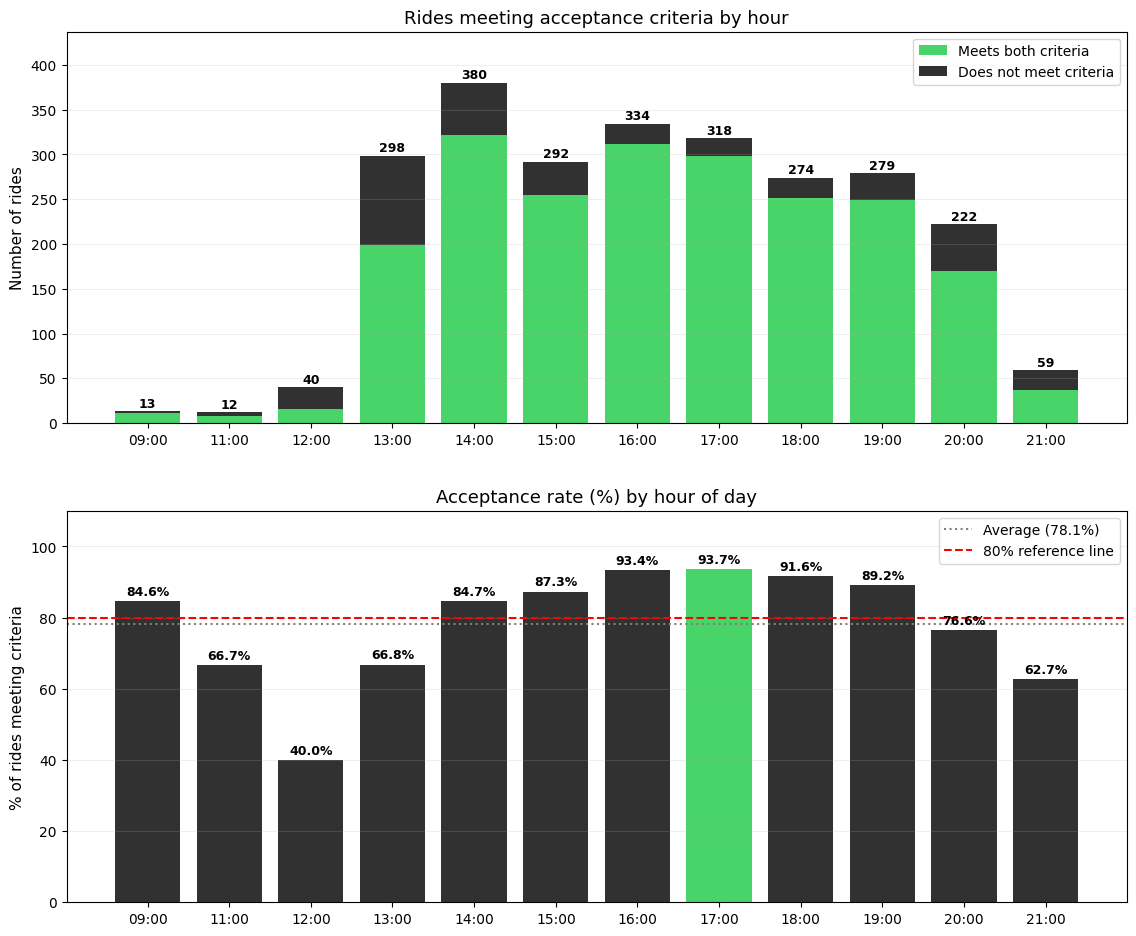

In [35]:
# Hourly acceptance rate — visual

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

hours_labels = [f"{h:02d}:00" for h in hour_criteria["Hour"]]
x = range(len(hour_criteria))

# Chart 1 — Stacked bar: meets vs not meets
ax1.bar(x, hour_criteria["meets_both"], color="#34d058",
        alpha=0.9, edgecolor="none", label="Meets both criteria")
ax1.bar(x, hour_criteria["not_meets"], color="#1a1a1a",
        alpha=0.9, edgecolor="none", label="Does not meet criteria",
        bottom=hour_criteria["meets_both"])

for i, (meets, total) in enumerate(zip(hour_criteria["meets_both"],
                                        hour_criteria["total_rides"])):
    ax1.text(i, total + 1.5, f"{total}", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax1.set_title("Rides meeting acceptance criteria by hour", fontsize=13)
ax1.set_ylabel("Number of rides", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(hours_labels, fontsize=10)
ax1.set_ylim(0, hour_criteria["total_rides"].max() * 1.15)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Acceptance rate % by hour
colors_rate = ["#34d058" if v == hour_criteria["pct_meets"].max()
               else "#1a1a1a" for v in hour_criteria["pct_meets"]]

bars2 = ax2.bar(x, hour_criteria["pct_meets"], color=colors_rate,
                alpha=0.9, edgecolor="none")

for bar, val in zip(bars2, hour_criteria["pct_meets"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax2.axhline(y=hour_criteria["pct_meets"].mean(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Average ({hour_criteria['pct_meets'].mean():.1f}%)")
ax2.axhline(y=80, color="red", linewidth=1.5, linestyle="--",
            label="80% reference line")

ax2.set_title("Acceptance rate (%) by hour of day", fontsize=13)
ax2.set_ylabel("% of rides meeting criteria", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(hours_labels, fontsize=10)
ax2.set_ylim(0, 110)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout(pad=3.0)
plt.savefig("../images/block5_hourly_acceptance.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 5 — Analysis of the question 13: At what time do more rides meet the acceptance criteria?

**Acceptance rate by hour (rides with ≥ 10 observations):**
| Hour | Total Rides | Meets Criteria | Rate |
|---|---|---|---|
| 09:00 | 13 | 11 | 84.6% |
| 11:00 | 12 | 8 | 66.7% |
| 12:00 | 40 | 16 | 40.0% ⚠️ |
| 13:00 | 298 | 199 | 66.8% |
| 14:00 | 380 | 322 | 84.7% |
| 15:00 | 292 | 255 | 87.3% |
| 16:00 | 334 | 312 | 93.4% |
| 17:00 | 318 | 298 | 93.7% ⭐ |
| 18:00 | 274 | 251 | 91.6% |
| 19:00 | 279 | 249 | 89.2% |
| 20:00 | 222 | 170 | 76.6% |
| 21:00 | 59 | 37 | 62.7% |

**Interpretation:**  
The 16:00–18:00 window is the "golden window" — it combines the
highest acceptance rates (91–94%) with strong ride volume.

**Key insight:**  
The pattern confirms that the driver's schedule (starting at 12:30)
captures the lower-quality early afternoon rides before the market
improves at 16:00.

**Practical conclusion:**  
If the daily earnings target is already met by 20:00, extending the
shift to 21:00 has an acceptance rate of 62.7% — still the lowest of
the main working hours.

### Question 14 — How close are results to the daily and weekly targets?

**Daily target:** 100€ gross  
**Weekly target:** 500€ net (after fuel and fleet costs)  
**Question:** How consistently are these targets achieved?

In [36]:
# Question 14: How close are daily and weekly results to the targets?
# Daily target: 100€ gross | Weekly target: 500€ net

FUEL_COST_PER_KM = 0.0976  # €/km (5.16L/100km × 1.892€/L)
FLEET_COST_PER_WEEK = 30   # € fixed weekly cost

# Daily gross earnings
daily_earnings = df.groupby("Date").agg(
    gross=("Driver_Earnings_EUR", "sum"),
    km=("Distance_Km", "sum")
).reset_index()

daily_earnings["fuel_cost"] = daily_earnings["km"] * FUEL_COST_PER_KM
daily_earnings["net"] = daily_earnings["gross"] - daily_earnings["fuel_cost"]
daily_earnings["hits_daily_target"] = daily_earnings["gross"] >= 100
daily_earnings["gap_to_target"] = daily_earnings["gross"] - 100

# Weekly aggregation
daily_earnings["Week"] = pd.to_datetime(daily_earnings["Date"]).dt.to_period("W")
weekly_earnings = daily_earnings.groupby("Week").agg(
    weekly_gross=("gross", "sum"),
    weekly_net_before_fleet=("net", "sum"),
    days_worked=("Date", "count")
).reset_index()

weekly_earnings["weekly_net"] = (weekly_earnings["weekly_net_before_fleet"]
                                  - FLEET_COST_PER_WEEK)
weekly_earnings["hits_weekly_target"] = weekly_earnings["weekly_net"] >= 500
weekly_earnings["gap_to_weekly"] = weekly_earnings["weekly_net"] - 500

# Print summary
print("DAILY TARGET (100€ gross)")
print("-" * 55)
print(f"Days analysed:          {len(daily_earnings)}")
print(f"Days hitting target:    {daily_earnings['hits_daily_target'].sum()} "
      f"({daily_earnings['hits_daily_target'].mean()*100:.1f}%)")
print(f"Days below target:      {(~daily_earnings['hits_daily_target']).sum()} "
      f"({(~daily_earnings['hits_daily_target']).mean()*100:.1f}%)")
print(f"Average daily gross:    {daily_earnings['gross'].mean():.2f}€")
print(f"Median daily gross:     {daily_earnings['gross'].median():.2f}€")
print(f"Best day:               {daily_earnings['gross'].max():.2f}€")
print(f"Worst day:              {daily_earnings['gross'].min():.2f}€")

print("\nWEEKLY TARGET (500€ net)")
print("-" * 55)
print(f"Weeks analysed:         {len(weekly_earnings)}")
print(f"Weeks hitting target:   {weekly_earnings['hits_weekly_target'].sum()} "
      f"({weekly_earnings['hits_weekly_target'].mean()*100:.1f}%)")
print(f"Weeks below target:     {(~weekly_earnings['hits_weekly_target']).sum()} "
      f"({(~weekly_earnings['hits_weekly_target']).mean()*100:.1f}%)")
print(f"Average weekly net:     {weekly_earnings['weekly_net'].mean():.2f}€")
print(f"Median weekly net:      {weekly_earnings['weekly_net'].median():.2f}€")
print(f"Best week:              {weekly_earnings['weekly_net'].max():.2f}€")
print(f"Worst week:             {weekly_earnings['weekly_net'].min():.2f}€")

DAILY TARGET (100€ gross)
-------------------------------------------------------
Days analysed:          152
Days hitting target:    99 (65.1%)
Days below target:      53 (34.9%)
Average daily gross:    105.18€
Median daily gross:     107.46€
Best day:               159.84€
Worst day:              44.98€

WEEKLY TARGET (500€ net)
-------------------------------------------------------
Weeks analysed:         26
Weeks hitting target:   12 (46.2%)
Weeks below target:     14 (53.8%)
Average weekly net:     494.96€
Median weekly net:      499.12€
Best week:              654.76€
Worst week:             160.37€


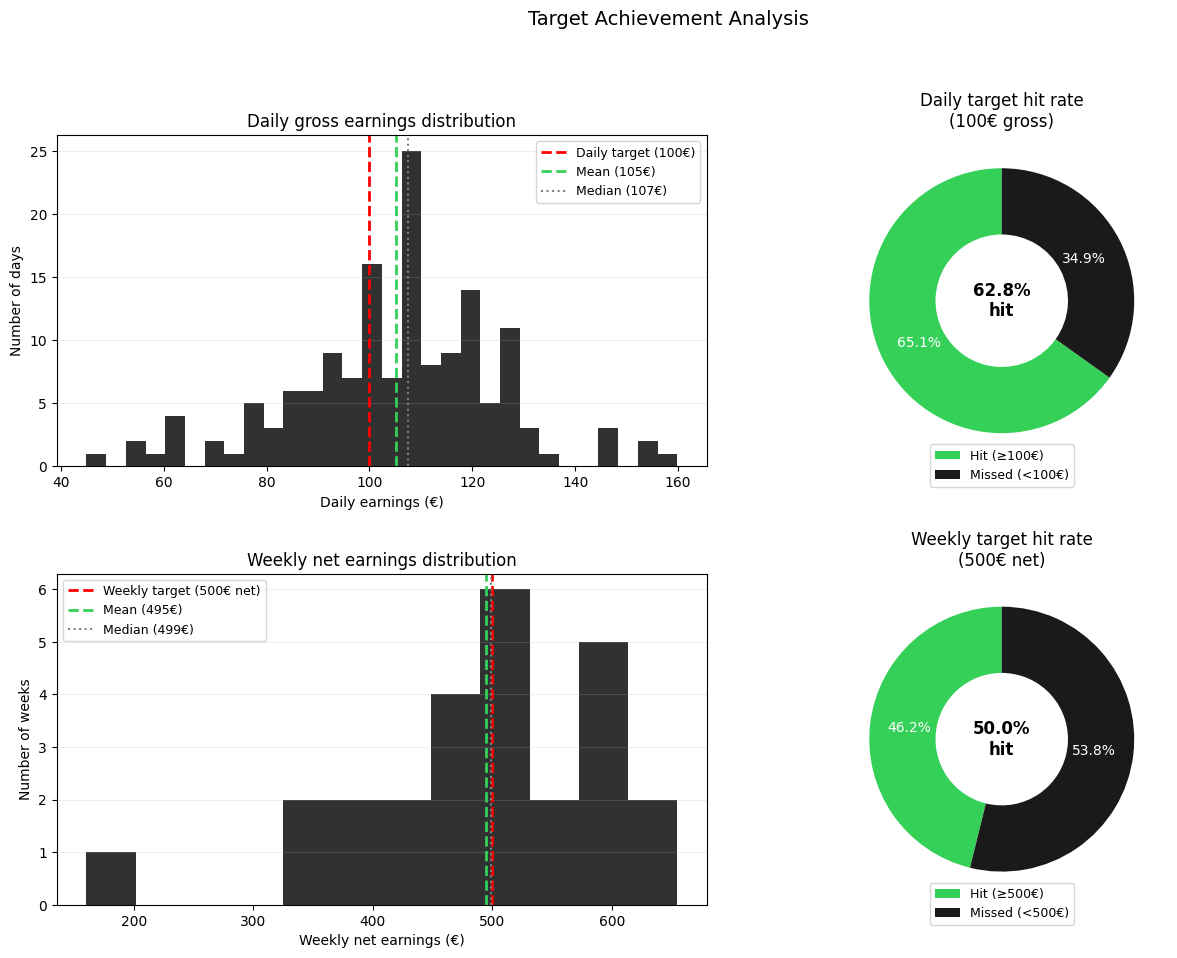

In [37]:
# Daily and weekly target achievement — visual

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Daily earnings distribution with target line
ax1.hist(daily_earnings["gross"], bins=30, color="#1a1a1a",
         edgecolor="none", alpha=0.9)
ax1.axvline(x=100, color="red", linewidth=2, linestyle="--",
            label="Daily target (100€)")
ax1.axvline(x=daily_earnings["gross"].mean(), color="#34d058",
            linewidth=2, linestyle="--",
            label=f"Mean ({daily_earnings['gross'].mean():.0f}€)")
ax1.axvline(x=daily_earnings["gross"].median(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Median ({daily_earnings['gross'].median():.0f}€)")
ax1.set_title("Daily gross earnings distribution", fontsize=12)
ax1.set_xlabel("Daily earnings (€)", fontsize=10)
ax1.set_ylabel("Number of days", fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Daily target hit rate (pie)
hit_counts = [daily_earnings["hits_daily_target"].sum(),
              (~daily_earnings["hits_daily_target"]).sum()]
ax2.pie(hit_counts, labels=None,
        autopct="%1.1f%%", colors=["#34d058", "#1a1a1a"],
        startangle=90, pctdistance=0.7,
        wedgeprops=dict(width=0.5),
        textprops=dict(color="white"))
ax2.text(0, 0, f"62.8%\nhit", ha="center", va="center",
         fontsize=12, fontweight="bold")
ax2.legend(["Hit (≥100€)", "Missed (<100€)"],
           loc="lower center", bbox_to_anchor=(0.5, -0.08), fontsize=9)
ax2.set_title("Daily target hit rate\n(100€ gross)", fontsize=12)

# Chart 3 — Weekly net earnings distribution
ax3.hist(weekly_earnings["weekly_net"], bins=12, color="#1a1a1a",
         edgecolor="none", alpha=0.9)
ax3.axvline(x=500, color="red", linewidth=2, linestyle="--",
            label="Weekly target (500€ net)")
ax3.axvline(x=weekly_earnings["weekly_net"].mean(), color="#34d058",
            linewidth=2, linestyle="--",
            label=f"Mean ({weekly_earnings['weekly_net'].mean():.0f}€)")
ax3.axvline(x=weekly_earnings["weekly_net"].median(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Median ({weekly_earnings['weekly_net'].median():.0f}€)")
ax3.set_title("Weekly net earnings distribution", fontsize=12)
ax3.set_xlabel("Weekly net earnings (€)", fontsize=10)
ax3.set_ylabel("Number of weeks", fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.2, axis="y")

# Chart 4 — Weekly target hit rate (pie)
hit_weekly = [weekly_earnings["hits_weekly_target"].sum(),
              (~weekly_earnings["hits_weekly_target"]).sum()]
ax4.pie(hit_weekly, labels=None,
        autopct="%1.1f%%", colors=["#34d058", "#1a1a1a"],
        startangle=90, pctdistance=0.7,
        wedgeprops=dict(width=0.5),
        textprops=dict(color="white"))
ax4.text(0, 0, f"50.0%\nhit", ha="center", va="center",
         fontsize=12, fontweight="bold")
ax4.legend(["Hit (≥500€)", "Missed (<500€)"],
           loc="lower center", bbox_to_anchor=(0.5, -0.08), fontsize=9)
ax4.set_title("Weekly target hit rate\n(500€ net)", fontsize=12)

plt.suptitle("Target Achievement Analysis", fontsize=14)
plt.tight_layout(pad=3.0)
plt.savefig("../images/block5_target_achievement.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 5 — Analysis of the question 14: How close are results to the daily and weekly targets?

**Daily target: 100€ gross**
| Metric | Value |
|---|---|
| Days analysed | 152 |
| Days hitting target | 99 (65.1%) |
| Average daily gross | 105.18 € |
| Median daily gross | 107.46 € |
| Best day | 159.84 € |
| Worst day | 44.98 € |

**Weekly target: 500€ net (after fuel and fleet costs)**
| Metric | Value |
|---|---|
| Weeks analysed | 26 |
| Weeks hitting target | 12 (46.2%) |
| Average weekly net | 494.96 € |
| Median weekly net | 499.12 € |
| Best week | 654.76 € |
| Worst week | 160.37 € |

**Interpretation:**  
The daily target (100€ gross) is achieved 65.1% of the time.

**Practical conclusion:**  
To reliably hit 500€/week net, the data suggests working close to
6 days per week at median daily performance (107€ gross).

### Question 15 — Is the working schedule (12:30–22:00) well dimensioned?

**Question:** Do the data support the current working hours, or would a different schedule be more efficient?  
**Method:** Rides grouped into three schedule zones — Early (before 13:00), Core (13:00–20:00), Late (after 20:00).

In [38]:
# Question 15: Is the working schedule (12:30–22:00) well dimensioned?
# Analysing earnings and acceptance rate at the edges of the schedule

# Define schedule zones
def schedule_zone(hour):
    if hour < 13:
        return "Early (before 13:00)"
    elif hour <= 20:
        return "Core (13:00–20:00)"
    else:
        return "Late (after 20:00)"

df["Schedule_Zone"] = df["Hour"].apply(schedule_zone)

zone_stats = df.groupby("Schedule_Zone").agg(
    total_rides=("Ride_ID", "count"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    meets_criteria=("meets_both", "sum"),
    total_earnings=("Driver_Earnings_EUR", "sum")
).reset_index()

zone_stats["pct_rides"] = (zone_stats["total_rides"] /
                            zone_stats["total_rides"].sum() * 100)
zone_stats["acceptance_rate"] = (zone_stats["meets_criteria"] /
                                  zone_stats["total_rides"] * 100)

print("SCHEDULE ZONE ANALYSIS")
print("-" * 65)
print(zone_stats[["Schedule_Zone", "total_rides", "pct_rides",
                  "avg_eur_per_hour", "avg_earnings",
                  "acceptance_rate", "total_earnings"]].to_string(index=False))

print("\nHOURLY BREAKDOWN AT SCHEDULE EDGES")
print("-" * 65)
edge_hours = df[df["Hour"].isin([12, 13, 20, 21])].groupby("Hour").agg(
    total_rides=("Ride_ID", "count"),
    avg_eur_per_hour=("eur_per_hour_ride", "mean"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    acceptance_rate=("meets_both", "mean")
).reset_index()
edge_hours["acceptance_rate"] = edge_hours["acceptance_rate"] * 100
print(edge_hours.to_string(index=False))

SCHEDULE ZONE ANALYSIS
-----------------------------------------------------------------
       Schedule_Zone  total_rides  pct_rides  avg_eur_per_hour  avg_earnings  acceptance_rate  total_earnings
  Core (13:00–20:00)         2397  94.332940         25.831229      6.249141        85.773884        14979.19
Early (before 13:00)           80   3.148367         24.953483      7.437625        57.500000          595.01
  Late (after 20:00)           64   2.518693         25.083226      6.445312        64.062500          412.50

HOURLY BREAKDOWN AT SCHEDULE EDGES
-----------------------------------------------------------------
 Hour  total_rides  avg_eur_per_hour  avg_earnings  acceptance_rate
   12           40         25.510506      7.997500        40.000000
   13          298         25.886898      6.883456        66.778523
   20          222         26.364034      6.405901        76.576577
   21           59         25.240865      6.428983        62.711864


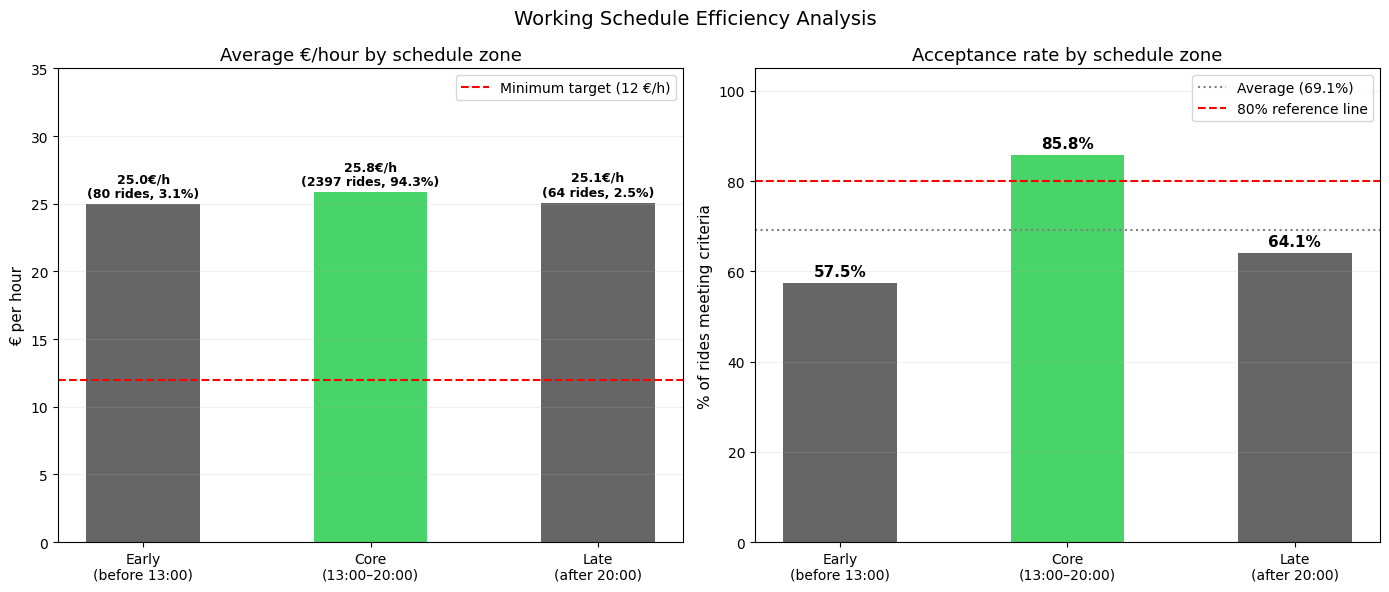

In [39]:
# Schedule zone analysis — visual

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

zone_order = ["Early (before 13:00)", "Core (13:00–20:00)", "Late (after 20:00)"]
zone_stats_ordered = zone_stats.set_index("Schedule_Zone").reindex(zone_order).reset_index()

colors_zone = ["#555555", "#34d058", "#555555"]

# Chart 1 — €/hour by zone
bars1 = ax1.bar(range(3), zone_stats_ordered["avg_eur_per_hour"],
                color=colors_zone, alpha=0.9, edgecolor="none", width=0.5)

for bar, val, rides, pct in zip(bars1, zone_stats_ordered["avg_eur_per_hour"],
                                  zone_stats_ordered["total_rides"],
                                  zone_stats_ordered["pct_rides"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}€/h\n({rides} rides, {pct:.1f}%)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.axhline(y=12, color="red", linewidth=1.5, linestyle="--",
            label="Minimum target (12 €/h)")
ax1.set_title("Average €/hour by schedule zone", fontsize=13)
ax1.set_ylabel("€ per hour", fontsize=11)
ax1.set_xticks(range(3))
ax1.set_xticklabels(["Early\n(before 13:00)", "Core\n(13:00–20:00)",
                      "Late\n(after 20:00)"], fontsize=10)
ax1.set_ylim(0, 35)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2, axis="y")

# Chart 2 — Acceptance rate by zone
bars2 = ax2.bar(range(3), zone_stats_ordered["acceptance_rate"],
                color=colors_zone, alpha=0.9, edgecolor="none", width=0.5)

for bar, val in zip(bars2, zone_stats_ordered["acceptance_rate"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

ax2.axhline(y=zone_stats_ordered["acceptance_rate"].mean(), color="gray",
            linewidth=1.5, linestyle=":",
            label=f"Average ({zone_stats_ordered['acceptance_rate'].mean():.1f}%)")
ax2.axhline(y=80, color="red", linewidth=1.5, linestyle="--",
            label="80% reference line")

ax2.set_title("Acceptance rate by schedule zone", fontsize=13)
ax2.set_ylabel("% of rides meeting criteria", fontsize=11)
ax2.set_xticks(range(3))
ax2.set_xticklabels(["Early\n(before 13:00)", "Core\n(13:00–20:00)",
                      "Late\n(after 20:00)"], fontsize=10)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2, axis="y")

plt.suptitle("Working Schedule Efficiency Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("../images/block5_schedule_zones.png", dpi=150, bbox_inches="tight")
plt.show()

### Block 5 — Analysis of the question 15: Is the working schedule (12:30–22:00) well dimensioned?

**Performance by schedule zone:**
| Zone | Rides | % | Avg €/h | Acceptance Rate |
|---|---|---|---|---|
| Early (before 13:00) | 80 | 3.1% | 25.0 €/h | 57.5% |
| Core (13:00–20:00) | 2,397 | 94.3% | 25.8 €/h | 85.8% ⭐ |
| Late (after 20:00) | 64 | 2.5% | 25.1 €/h | 64.1% |

**Edge hours detail:**
| Hour | Rides | Avg €/h | Acceptance Rate |
|---|---|---|---|
| 12:00 | 40 | 25.5 €/h | 40.0% ⚠️ |
| 13:00 | 298 | 25.9 €/h | 66.8% |
| 20:00 | 222 | 26.4 €/h | 76.6% |
| 21:00 | 59 | 25.2 €/h | 62.7% |

**Interpretation:**  
The three schedule zones show nearly identical €/hour efficiency
(25.0–25.8 €/h) — working earlier or later doesn't reduce hourly
returns. Acceptance rate drops sharply outside the Core zone (85.8% →
~60%), confirming rides before 13:00 and after 20:00 are
systematically lower quality.

**Key insight:**  
The current schedule is well calibrated — 94.3% of all rides fall
within the Core zone. The 12:00 hour is the least efficient by
acceptance rate (40.0%).

**Practical conclusion:**  
Extending the shift beyond 21:00 is not clearly justified — acceptance
rate there is 62.7% and volume remains low (59 rides). Starting at
13:00 instead of 12:30 would sacrifice 80 rides (3.1% of total) while
eliminating the worst-performing hour.

Note: Please keep in mind that the standard schedule is from 12:30 PM to 10:00 PM; trips outside these hours are atypical due to personal reasons.

### Question 16 — Does more km per day lead to higher net profit?

**Question:** Is driving more km always better for net profit, or does fuel cost erode the gains?  
**Method:** Scatter plot with colour dimension (number of rides) to reveal the true driver of net profit.

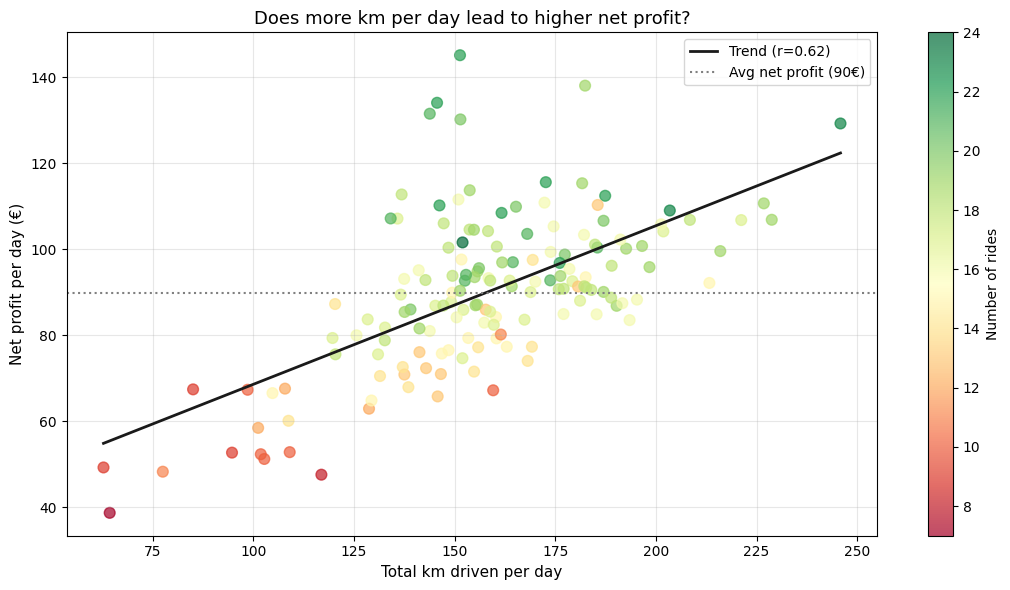

Correlation (r): 0.623
Slope: 0.369 € net profit per extra km
P-value: 0.0000 (statistically significant)

Avg daily km:        157.6 km
Avg daily net profit: 89.80 €
Days where net > gross * 0.9: 3


In [40]:
# Question 16: Does more km per day lead to higher net profit?
# More km = more fuel cost — does it translate to higher net profit?

FUEL_COST_PER_KM = 0.0976

daily_full = df.groupby("Date").agg(
    total_km=("Distance_Km", "sum"),
    gross_earnings=("Driver_Earnings_EUR", "sum"),
    total_rides=("Ride_ID", "count")
).reset_index()

daily_full["fuel_cost"] = daily_full["total_km"] * FUEL_COST_PER_KM
daily_full["net_profit"] = daily_full["gross_earnings"] - daily_full["fuel_cost"]

slope, intercept, r_value, p_value, std_err = stats.linregress(
    daily_full["total_km"], daily_full["net_profit"]
)

fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    daily_full["total_km"],
    daily_full["net_profit"],
    c=daily_full["total_rides"],
    cmap="RdYlGn",
    alpha=0.7, s=60
)

plt.colorbar(scatter, ax=ax, label="Number of rides")

x_line = np.linspace(daily_full["total_km"].min(),
                     daily_full["total_km"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#1a1a1a", linewidth=2,
        label=f"Trend (r={r_value:.2f})")

ax.axhline(y=daily_full["net_profit"].mean(), color="gray",
           linewidth=1.5, linestyle=":",
           label=f"Avg net profit ({daily_full['net_profit'].mean():.0f}€)")

ax.set_xlabel("Total km driven per day", fontsize=11)
ax.set_ylabel("Net profit per day (€)", fontsize=11)
ax.set_title("Does more km per day lead to higher net profit?", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/block5_km_vs_net_profit.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation (r): {r_value:.3f}")
print(f"Slope: {slope:.3f} € net profit per extra km")
print(f"P-value: {p_value:.4f} "
      f"({'statistically significant' if p_value < 0.05 else 'not statistically significant'})")
print(f"\nAvg daily km:        {daily_full['total_km'].mean():.1f} km")
print(f"Avg daily net profit: {daily_full['net_profit'].mean():.2f} €")
print(f"Days where net > gross * 0.9: "
      f"{(daily_full['net_profit'] > daily_full['gross_earnings'] * 0.9).sum()}")

### Block 5 — Analysis of the question 16: Does more km per day lead to higher net profit?

**Result:** Moderate-to-strong positive correlation (r = 0.623, p < 0.001)

**Key numbers:**
- Slope: +0.37 € net profit per extra km driven
- Average daily km: 157.6 km
- Average daily net profit: 89.80 €
- Days where net profit > 90% of gross: 3

**Interpretation:**  
More km per day is positively correlated with higher net profit. The
colour dimension (number of rides) reveals the real driver: days with
more rides consistently outperform the trend line even at moderate km
levels.

**Key insight:**  
Km alone doesn't fully explain net profit — ride density matters more.

**Practical conclusion:**  
Maximising the number of rides — not the total km — is the primary
lever for daily net profit, reinforcing Question 4.

---
## Final Validation

A single consolidated summary of the full dataset, used as the cross-validation
reference point against notebook 02 (SQL) and the Power BI dashboard.

In [41]:
# FINAL VALIDATION — cross-check reference for notebook 02 and Power BI

FUEL_COST_PER_KM = 0.0976
FLEET_COST_PER_WEEK = 30

total_rides = len(df)
days_worked = df["Date"].nunique()
total_gross = df["Driver_Earnings_EUR"].sum()
total_km = df["Distance_Km"].sum()
total_hours = df["Duration_Min"].sum() / 60

days_range = (pd.to_datetime(df["Date"]).max() -
              pd.to_datetime(df["Date"]).min()).days + 1
total_fuel_cost = total_km * FUEL_COST_PER_KM
total_fleet_cost = round(days_range / 7) * FLEET_COST_PER_WEEK
net_profit = total_gross - total_fuel_cost - total_fleet_cost
avg_eur_per_hour = total_gross / total_hours

print("=" * 59)
print("FINAL VALIDATION — FULL DATASET SUMMARY")
print("=" * 59)
print(f"  Total rides:                     {total_rides:,}")
print(f"  Days worked:                     {days_worked}")
print(f"  Total gross earnings:            {total_gross:,.2f} €")
print(f"  Total fuel cost:                 {total_fuel_cost:,.2f} €")
print(f"  Total fleet cost:                {total_fleet_cost:,.2f} €")
print(f"  Net profit after all costs:      {net_profit:,.2f} €")
print(f"  Average €/hour:                  {avg_eur_per_hour:.2f}")
print("=" * 59)
print()
print("Compare these values against:")
print("  - SQL         -> notebook 02, Final Summary Query")
print("  - Power BI    -> Net_Profit_EUR measure on Page 1")


FINAL VALIDATION — FULL DATASET SUMMARY
  Total rides:                     2,541
  Days worked:                     152
  Total gross earnings:            15,986.70 €
  Total fuel cost:                 2,337.63 €
  Total fleet cost:                780.00 €
  Net profit after all costs:      12,869.07 €
  Average €/hour:                  23.52

Compare these values against:
  - SQL         -> notebook 02, Final Summary Query
  - Power BI    -> Net_Profit_EUR measure on Page 1
